# 📊 Matplotlib & Seaborn 데이터 시각화 완전정복
## 초급부터 고급까지, 실전 데이터로 배우는 시각화

### 수업 목표
- **Matplotlib** 기본 문법과 다양한 차트 유형을 익힌다
- **Seaborn**의 통계 시각화 기능을 활용할 수 있다
- 서브플롯, 스타일링, 주석 등 고급 기법을 익힌다
- 실전 데이터로 의미 있는 대시보드를 구성할 수 있다

### 수업 구성 (3시간)
| 시간 | 내용 | 사용 데이터 |
|------|------|------------|
| 1교시 (50분) | Matplotlib 기초 — 선, 막대, 히스토그램, 산점도, 파이 차트 | 컴퓨터 가격, 상하수도 요금 |
| 2교시 (50분) | Seaborn 기초~중급 — 통계 차트, 히트맵, 관계도 | Spotify, Titanic, 사업자현황 |
| 3교시 (80분) | 고급 시각화 + 실전 대시보드 + 연습문제 | 지하철 혼잡도, 주택가격 + 전체 |

### 사용 데이터셋
| 데이터 | 설명 | 건수 |
|--------|------|------|
| computer_prices_all.csv | 컴퓨터 가격 정보 | 100,000건 |
| 경상북도 안동시_상하수도요금정보 | 상하수도 사용량/요금 | 471,984건 |
| spotify-2023.csv | Spotify 인기곡 정보 | 953건 |
| titanic_train.csv | 타이타닉 생존자 정보 | 891건 |
| 국세청_사업자현황_성별 | 시도별 사업자 현황 | 8,527건 |
| 서울교통공사_혼잡도 | 지하철 시간대별 혼잡도 | 1,668건 |
| california_housing_test.csv | 캘리포니아 주택 가격 | 3,000건 |

---

# 🕐 1교시: Matplotlib 기초
---
## 1-1. 라이브러리 임포트 및 데이터 로드

In [1]:
# 필요한 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   # matplotlib의 핵심 모듈
import seaborn as sns              # 통계 시각화 라이브러리
import warnings
warnings.filterwarnings('ignore')  # 경고 메시지 숨김

# 한글 폰트 설정 (macOS 기준)
plt.rcParams['font.family'] = 'AppleGothic'        # macOS 한글 폰트
plt.rcParams['axes.unicode_minus'] = False          # 마이너스 부호 깨짐 방지
plt.rcParams['figure.figsize'] = (10, 6)            # 기본 그래프 크기
plt.rcParams['figure.dpi'] = 100                    # 해상도

# Jupyter 노트북에서 그래프 인라인 표시
%matplotlib inline

print("라이브러리 로드 완료!")
print(f"matplotlib 버전: {plt.matplotlib.__version__}")
print(f"seaborn 버전: {sns.__version__}")

라이브러리 로드 완료!
matplotlib 버전: 3.8.3
seaborn 버전: 0.13.2


In [2]:
# 데이터 로드 (이번 수업에서 사용할 7개 데이터셋)
# 1) 컴퓨터 가격 데이터
df_comp = pd.read_csv('pandas/data/computer_prices_all.csv')

# 2) 상하수도 요금 데이터
df_water = pd.read_csv('pandas/data/경상북도 안동시_상하수도요금정보_20251124.csv', encoding='cp949')

# 3) Spotify 2023 인기곡
df_spotify = pd.read_csv('pandas/data/spotify-2023.csv', encoding='latin-1')

# 4) 타이타닉 생존 데이터
df_titanic = pd.read_csv('pandas/data/titanic_train.csv')

# 5) 국세청 사업자현황
df_biz = pd.read_csv('pandas/data/국세청_사업자현황_성별_20240930.csv', encoding='cp949')

# 6) 서울 지하철 혼잡도
df_subway = pd.read_csv('pandas/data/서울교통공사_ 혼잡도_20171231.csv', encoding='cp949')

# 7) 캘리포니아 주택 가격
df_housing = pd.read_csv('pandas/data/california_housing_test.csv')

print("=== 데이터 로드 완료 ===")
for name, df in [('컴퓨터 가격', df_comp), ('상하수도 요금', df_water), ('Spotify', df_spotify),
                  ('타이타닉', df_titanic), ('사업자현황', df_biz), ('지하철 혼잡도', df_subway),
                  ('주택 가격', df_housing)]:
    print(f"  {name}: {df.shape[0]:>8,}행 × {df.shape[1]}열")

=== 데이터 로드 완료 ===
  컴퓨터 가격:  100,000행 × 33열
  상하수도 요금:  471,984행 × 6열
  Spotify:      953행 × 24열
  타이타닉:      891행 × 8열
  사업자현황:    8,527행 × 13열
  지하철 혼잡도:    1,668행 × 44열
  주택 가격:    3,000행 × 9열


## 1-2. Matplotlib 기본 구조

> Matplotlib의 핵심 개념:
> - **Figure**: 전체 그림 (캔버스)
> - **Axes**: 개별 그래프 영역 (하나의 Figure에 여러 Axes 가능)
> - **plt 방식**: 빠르고 간단 (`plt.plot()`, `plt.bar()`)
> - **객체지향 방식**: 세밀한 제어 (`fig, ax = plt.subplots()`)
>
> ```python
> # 방법 1: plt 방식 (간단)
> plt.plot(x, y)
> plt.title('제목')
> plt.show()
>
> # 방법 2: 객체지향 방식 (권장)
> fig, ax = plt.subplots()
> ax.plot(x, y)
> ax.set_title('제목')
> plt.show()
> ```

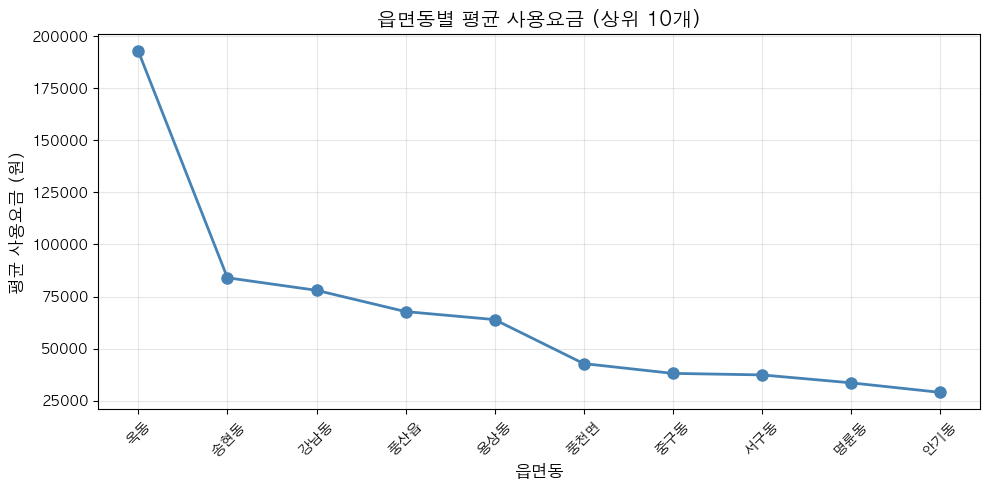

In [3]:
# 가장 기본적인 선 그래프 (Line Plot)
# 상하수도 데이터: 읍면동별 평균 사용요금

# 데이터 준비 - 읍면동별 평균 요금 (상위 10개 지역)
dong_avg = df_water.groupby('읍면동명')['사용요금'].mean().sort_values(ascending=False).head(10)

# plt 방식 - 빠르고 간편한 시각화
plt.figure(figsize=(10, 5))                          # 그래프 크기 설정
plt.plot(dong_avg.index, dong_avg.values,            # x축: 읍면동명, y축: 평균요금
         marker='o',                                  # 데이터 포인트 마커
         color='steelblue',                           # 선 색상
         linewidth=2,                                 # 선 두께
         markersize=8)                                # 마커 크기

plt.title('읍면동별 평균 사용요금 (상위 10개)', fontsize=14, fontweight='bold')  # 제목
plt.xlabel('읍면동', fontsize=12)                     # x축 라벨
plt.ylabel('평균 사용요금 (원)', fontsize=12)          # y축 라벨
plt.xticks(rotation=45)                               # x축 라벨 회전
plt.grid(True, alpha=0.3)                             # 격자선 (투명도 0.3)
plt.tight_layout()                                    # 레이아웃 자동 조정
plt.show()

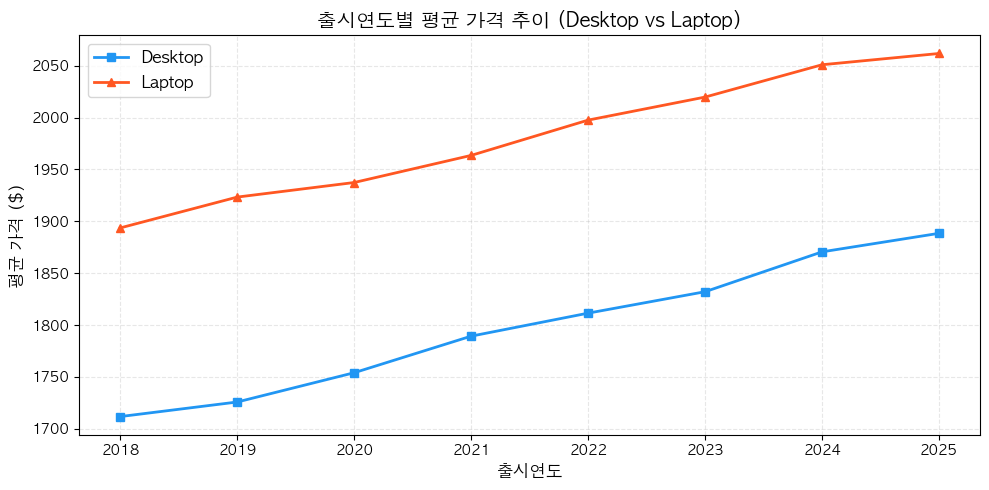

In [4]:
# 여러 선을 하나의 그래프에 그리기 + 범례(legend)
# 컴퓨터 데이터: 출시연도별 Desktop vs Laptop 평균 가격 추이

# 데이터 준비
yearly_price = df_comp.groupby(['release_year', 'device_type'])['price'].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 5))              # 객체지향 방식

# 각 기기유형별 선 그래프
ax.plot(yearly_price.index, yearly_price['Desktop'],
        marker='s', label='Desktop', color='#2196F3', linewidth=2)
ax.plot(yearly_price.index, yearly_price['Laptop'],
        marker='^', label='Laptop', color='#FF5722', linewidth=2)

ax.set_title('출시연도별 평균 가격 추이 (Desktop vs Laptop)', fontsize=14, fontweight='bold')
ax.set_xlabel('출시연도', fontsize=12)
ax.set_ylabel('평균 가격 ($)', fontsize=12)
ax.legend(fontsize=12, loc='upper left')              # 범례 표시
ax.grid(True, alpha=0.3, linestyle='--')              # 점선 격자
plt.tight_layout()
plt.show()

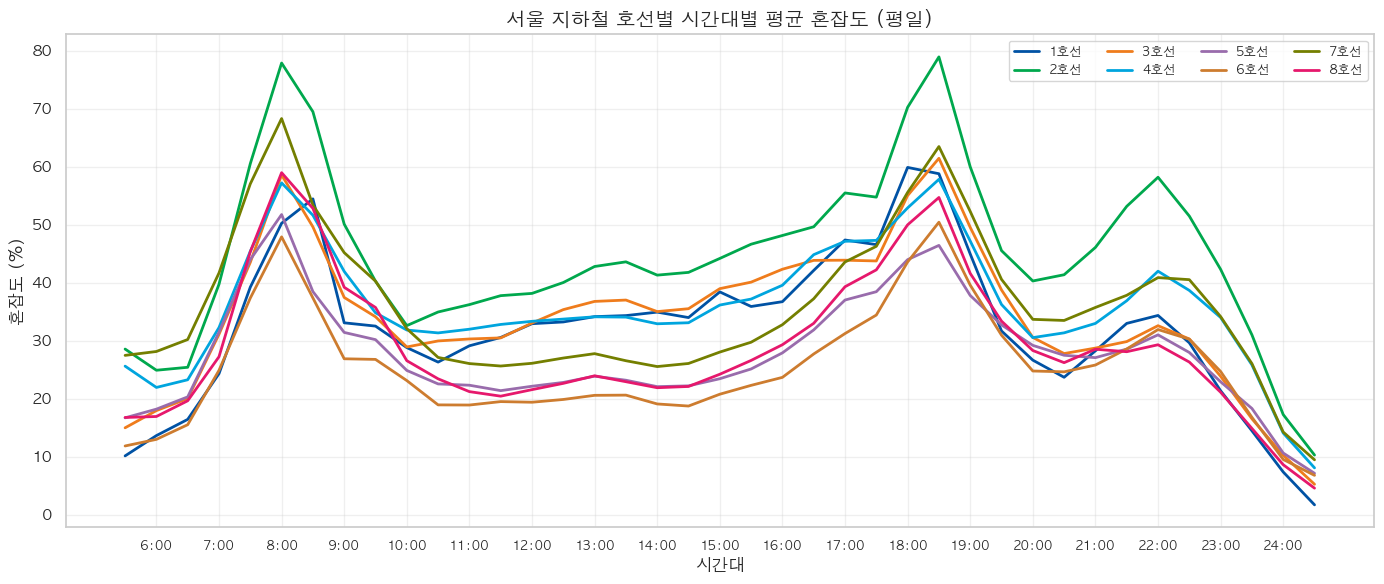

In [36]:
# 서울교통공사 호선별 시간대별 평균 혼잡도 라인 그래프 (평일)

# 시간대 컬럼 추출
time_cols = [c for c in df_subway.columns if '~' in c]

# 평일 1~8호선만 필터링 후 호선별 평균
main_lines = ['1', '2', '3', '4', '5', '6', '7', '8']
line_avg = df_subway[
    (df_subway['요일'] == '평일') & (df_subway['호선'].isin(main_lines))
].groupby('호선')[time_cols].mean()

# 호선별 색상 (실제 노선 색상)
colors = {'1':'#0052A4', '2':'#00A84D', '3':'#EF7C1C', '4':'#00A5DE',
           '5':'#996CAC', '6':'#CD7C2F', '7':'#747F00', '8':'#E6186C'}

fig, ax = plt.subplots(figsize=(14, 6))

# 호선별 라인 그래프
for line_num in main_lines:
    if line_num in line_avg.index:
        ax.plot(line_avg.loc[line_num].values,
                color=colors[line_num], linewidth=2,
                label=f'{line_num}호선')

# x축 라벨: 정각(:00)만 표시 (39개 중 20개만 표시하여 가독성 확보)
labels = [c.replace('~ (%)', '').strip() for c in time_cols]
major_idx = [i for i, l in enumerate(labels) if l.endswith(':00')]
ax.set_xticks(major_idx)
ax.set_xticklabels([labels[i] for i in major_idx], fontsize=9)

ax.set_title('서울 지하철 호선별 시간대별 평균 혼잡도 (평일)', fontsize=14, fontweight='bold')
ax.set_xlabel('시간대', fontsize=12)
ax.set_ylabel('혼잡도 (%)', fontsize=12)
ax.legend(fontsize=9, ncol=4)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 1-3. 막대 그래프 (Bar Chart)

> 범주형 데이터의 크기를 비교할 때 가장 많이 사용되는 차트입니다.
> - `plt.bar()` / `ax.bar()`: 수직 막대
> - `plt.barh()` / `ax.barh()`: 수평 막대

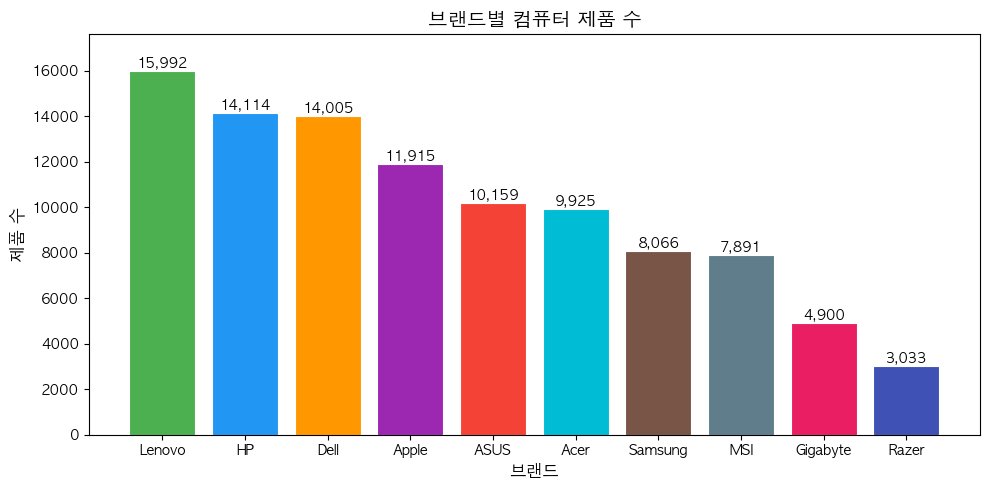

In [6]:
# 기본 수직 막대 그래프
# 컴퓨터 데이터: 브랜드별 제품 수

brand_counts = df_comp['brand'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))

# 막대 그래프 그리기
bars = ax.bar(brand_counts.index, brand_counts.values,
              color=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#F44336',
                     '#00BCD4', '#795548', '#607D8B', '#E91E63', '#3F51B5'],
              edgecolor='white',                      # 막대 테두리 색
              linewidth=0.8)

# 막대 위에 값 표시
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:,.0f}',                          # 천 단위 콤마
            ha='center', va='bottom', fontsize=10)

ax.set_title('브랜드별 컴퓨터 제품 수', fontsize=14, fontweight='bold')
ax.set_xlabel('브랜드', fontsize=12)
ax.set_ylabel('제품 수', fontsize=12)
ax.set_ylim(0, brand_counts.max() * 1.1)             # y축 여유 공간
plt.tight_layout()
plt.show()

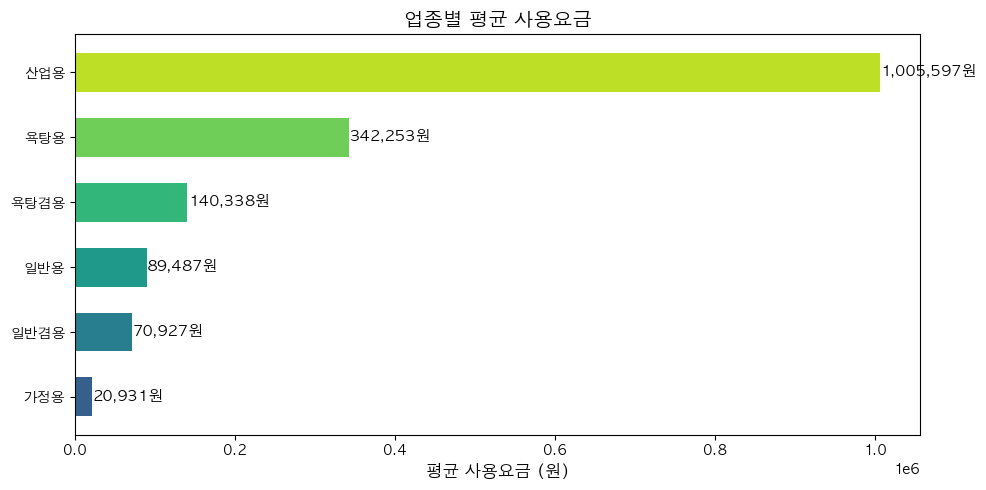

In [7]:
# 수평 막대 그래프 (barh) - 긴 라벨명에 유리
# 상하수도: 업종별 평균 사용요금

usage_by_type = df_water.groupby('업종')['사용요금'].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))

# 수평 막대 그래프
bars = ax.barh(usage_by_type.index, usage_by_type.values,
               color=plt.cm.viridis(np.linspace(0.3, 0.9, len(usage_by_type))),  # 컬러맵 사용
               height=0.6)

# 막대 끝에 값 표시
for bar in bars:
    width = bar.get_width()
    ax.text(width + 500, bar.get_y() + bar.get_height()/2.,
            f'{width:,.0f}원', ha='left', va='center', fontsize=11)

ax.set_title('업종별 평균 사용요금', fontsize=14, fontweight='bold')
ax.set_xlabel('평균 사용요금 (원)', fontsize=12)
plt.tight_layout()
plt.show()

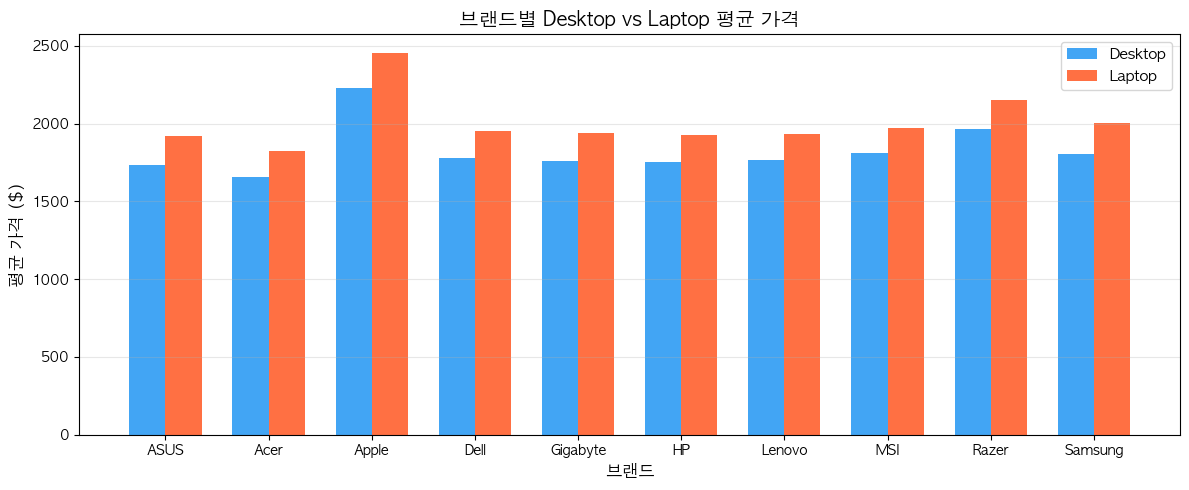

In [8]:
# 그룹 막대 그래프 (Grouped Bar Chart)
# 컴퓨터 데이터: 브랜드별 Desktop/Laptop 평균 가격 비교

brand_type_price = df_comp.groupby(['brand', 'device_type'])['price'].mean().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(brand_type_price.index))   # x 위치
width = 0.35                                    # 막대 너비

# 두 그룹의 막대를 나란히 배치
bars1 = ax.bar(x - width/2, brand_type_price['Desktop'], width,
               label='Desktop', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, brand_type_price['Laptop'], width,
               label='Laptop', color='#FF5722', alpha=0.85)

ax.set_title('브랜드별 Desktop vs Laptop 평균 가격', fontsize=14, fontweight='bold')
ax.set_xlabel('브랜드', fontsize=12)
ax.set_ylabel('평균 가격 ($)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(brand_type_price.index)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

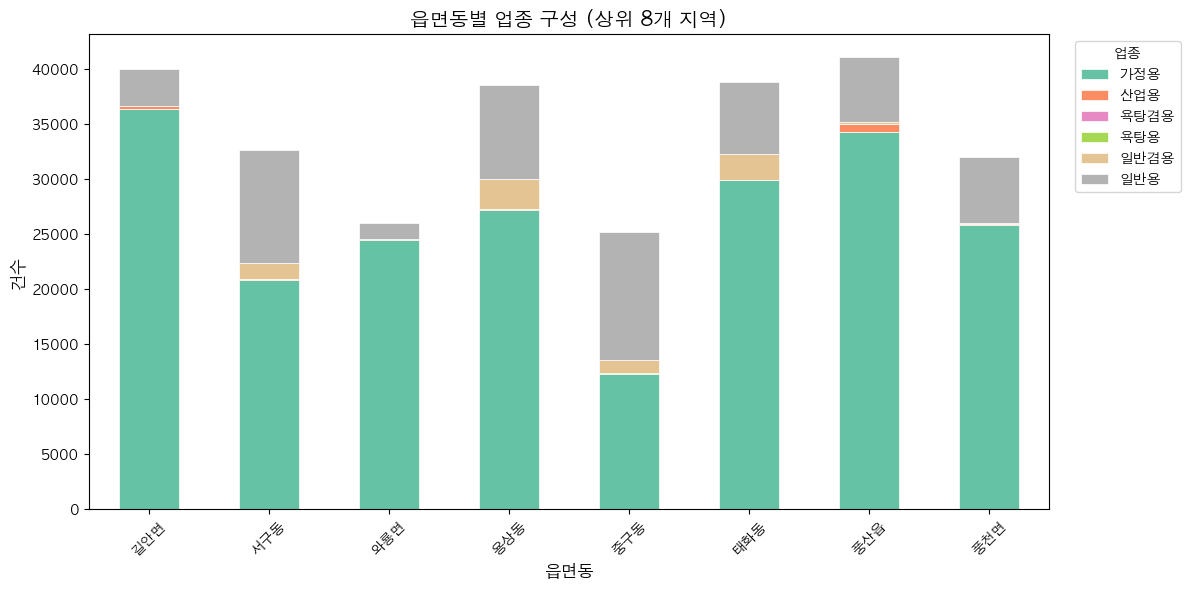

In [9]:
# 누적 막대 그래프 (Stacked Bar Chart)
# 상하수도 데이터: 읍면동별 업종별 건수 구성비

# 데이터 준비 - 상위 8개 읍면동의 업종별 건수
top_dongs = df_water['읍면동명'].value_counts().head(8).index
dong_type = df_water[df_water['읍면동명'].isin(top_dongs)].groupby(
    ['읍면동명', '업종']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))

# 누적 막대 그래프 (DataFrame의 plot 메서드 활용)
dong_type.plot(kind='bar', stacked=True, ax=ax,
               colormap='Set2', edgecolor='white', linewidth=0.5)

ax.set_title('읍면동별 업종 구성 (상위 8개 지역)', fontsize=14, fontweight='bold')
ax.set_xlabel('읍면동', fontsize=12)
ax.set_ylabel('건수', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.legend(title='업종', bbox_to_anchor=(1.02, 1), loc='upper left')  # 범례를 그래프 밖에 배치
plt.tight_layout()
plt.show()

## 1-4. 히스토그램 (Histogram)

> 수치형 데이터의 **분포(빈도)**를 시각화합니다. 막대 그래프와 달리 **연속형 데이터**에 사용합니다.
> - `bins`: 구간(막대) 개수
> - `density=True`: 확률 밀도로 표시 (면적 합 = 1)

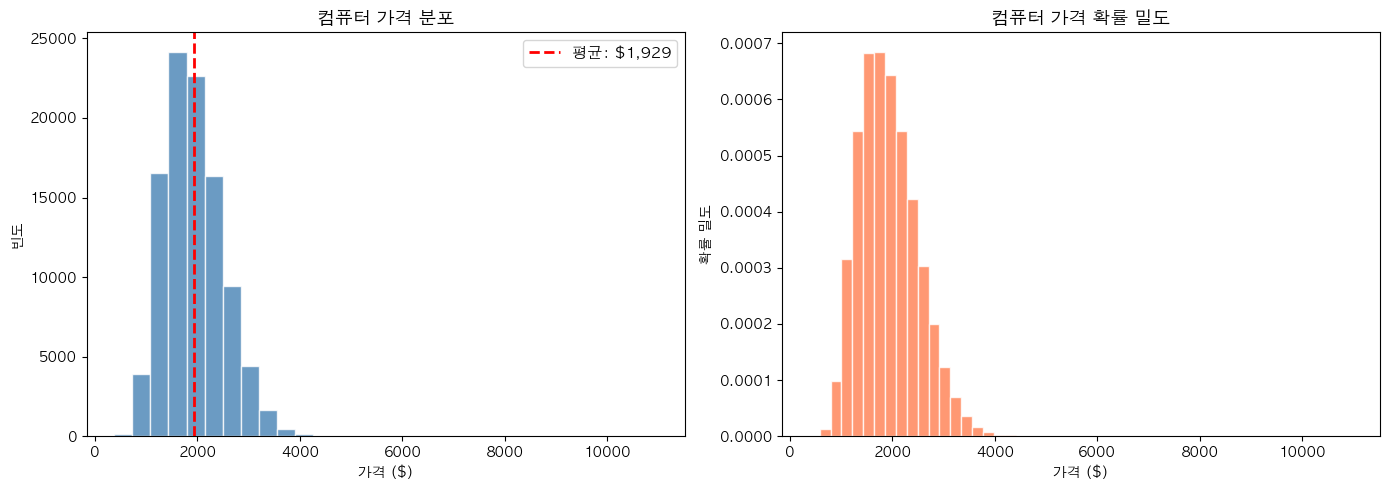

In [10]:
# 기본 히스토그램
# 컴퓨터 데이터: 가격 분포

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 좌측: 기본 히스토그램
axes[0].hist(df_comp['price'], bins=30,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('컴퓨터 가격 분포', fontsize=13, fontweight='bold')
axes[0].set_xlabel('가격 ($)')
axes[0].set_ylabel('빈도')
axes[0].axvline(df_comp['price'].mean(), color='red', linestyle='--',
                linewidth=2, label=f"평균: ${df_comp['price'].mean():,.0f}")
axes[0].legend(fontsize=11)

# 우측: bins 수 조절 + 밀도(density)
axes[1].hist(df_comp['price'], bins=50, density=True,
             color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('컴퓨터 가격 확률 밀도', fontsize=13, fontweight='bold')
axes[1].set_xlabel('가격 ($)')
axes[1].set_ylabel('확률 밀도')

plt.tight_layout()
plt.show()

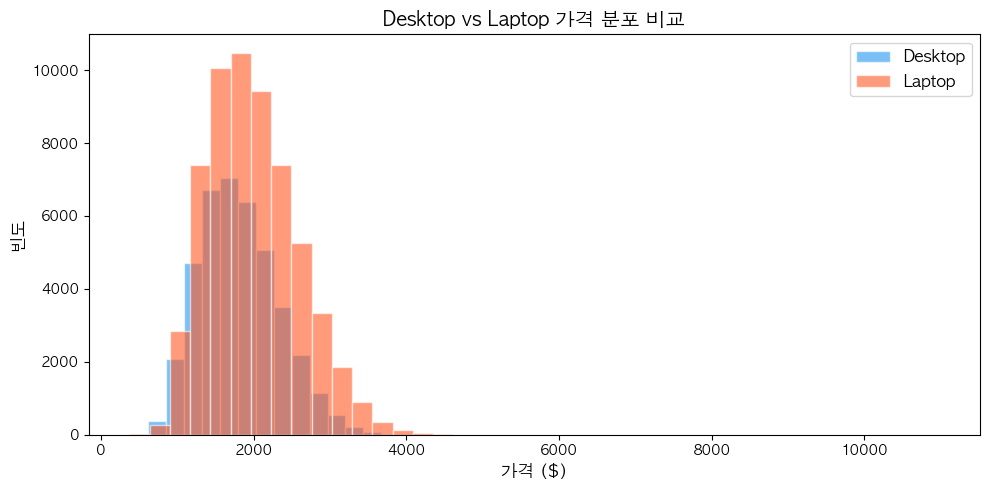

In [11]:
# 겹쳐 그리기 (alpha로 투명도 조절)
# Desktop과 Laptop의 가격 분포 비교

fig, ax = plt.subplots(figsize=(10, 5))

# 두 그룹의 히스토그램을 겹쳐 그리기
ax.hist(df_comp[df_comp['device_type'] == 'Desktop']['price'],
        bins=40, alpha=0.6, color='#2196F3', label='Desktop', edgecolor='white')
ax.hist(df_comp[df_comp['device_type'] == 'Laptop']['price'],
        bins=40, alpha=0.6, color='#FF5722', label='Laptop', edgecolor='white')

ax.set_title('Desktop vs Laptop 가격 분포 비교', fontsize=14, fontweight='bold')
ax.set_xlabel('가격 ($)', fontsize=12)
ax.set_ylabel('빈도', fontsize=12)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

## 1-5. 산점도 (Scatter Plot)

> 두 수치형 변수 간의 **관계(상관관계)**를 시각화합니다.
> 점의 색상, 크기로 추가 차원의 정보를 표현할 수 있습니다.

In [ ]:
# 기본 산점도 + 색상/크기로 다차원 표현
# 컴퓨터 데이터: RAM vs 가격, 색상=기기유형, 크기=스토리지

# 샘플 추출 (10만 건 전체를 그리면 느리므로)
sample = df_comp.sample(2000, random_state=42)

# Desktop / Laptop 각각 나눠서 그리기
colors = {'Desktop': '#2196F3', 'Laptop': '#FF5722'}
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (dtype, group) in zip(axes, sample.groupby('device_type')):
    ax.scatter(group['ram_gb'], group['price'],
               c=colors[dtype],
               s=group['storage_gb'] / 20,           # 스토리지 크기에 비례
               alpha=0.5,
               edgecolors='white', linewidth=0.3)
    ax.set_title(f'{dtype} — RAM vs 가격 (크기=스토리지)', fontsize=13, fontweight='bold')
    ax.set_xlabel('RAM (GB)', fontsize=12)
    ax.set_ylabel('가격 ($)', fontsize=12)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

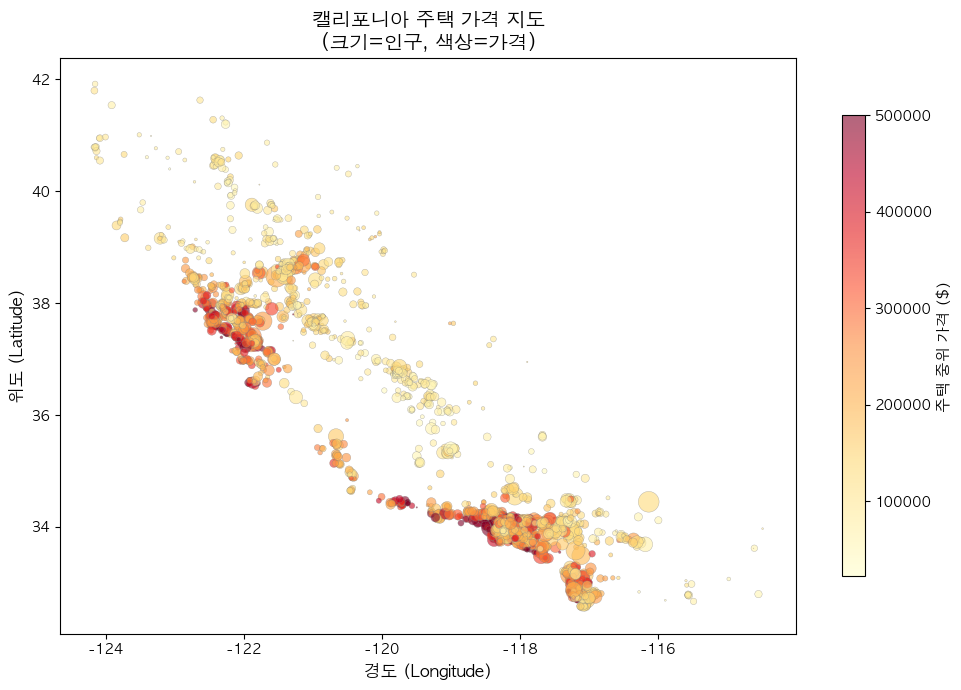

In [13]:
# 컬러맵 산점도 (연속형 색상) + 컬러바
# 캘리포니아 주택: 위치(위도/경도) + 주택가격을 색상으로

fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(df_housing['longitude'], df_housing['latitude'],
                     c=df_housing['median_house_value'],   # 색상 = 주택 가격
                     cmap='YlOrRd',                         # 컬러맵 (노랑→빨강)
                     s=df_housing['population'] / 50,       # 크기 = 인구
                     alpha=0.6,
                     edgecolors='gray', linewidth=0.3)

# 컬러바 추가
cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
cbar.set_label('주택 중위 가격 ($)', fontsize=11)

ax.set_title('캘리포니아 주택 가격 지도\n(크기=인구, 색상=가격)', fontsize=14, fontweight='bold')
ax.set_xlabel('경도 (Longitude)', fontsize=12)
ax.set_ylabel('위도 (Latitude)', fontsize=12)
plt.tight_layout()
plt.show()

## 1-6. 파이 차트 (Pie Chart) & 도넛 차트

> 전체 대비 **비율/구성비**를 시각화합니다. 항목이 5개 이하일 때 효과적입니다.

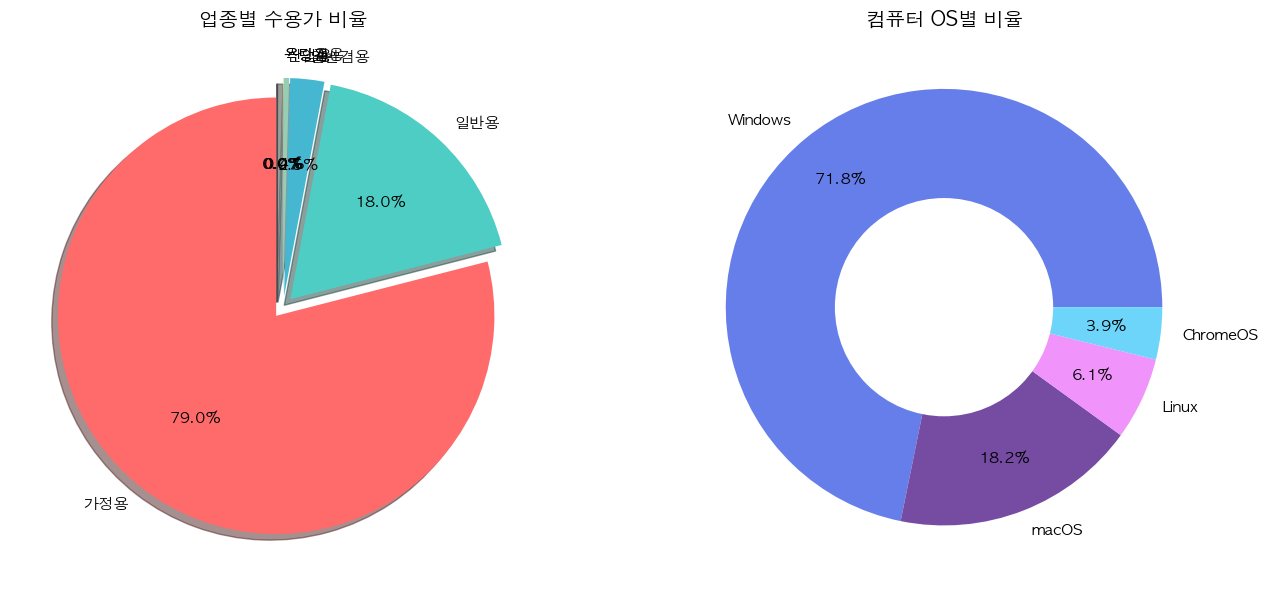

In [14]:
# 파이 차트 + 도넛 차트
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- 좌측: 파이 차트 ---
# 상하수도 업종별 비율
type_counts = df_water['업종'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
explode = [0.05] * len(type_counts)                   # 모든 조각 약간 분리

axes[0].pie(type_counts.values, labels=type_counts.index,
            autopct='%1.1f%%',                         # 비율 표시
            colors=colors,
            explode=explode,
            shadow=True,                                # 그림자 효과
            startangle=90,                              # 시작 각도
            textprops={'fontsize': 11})
axes[0].set_title('업종별 수용가 비율', fontsize=14, fontweight='bold')

# --- 우측: 도넛 차트 ---
# 컴퓨터 OS별 비율
os_counts = df_comp['os'].value_counts()
colors2 = ['#667eea', '#764ba2', '#f093fb', '#6dd5fa']

wedges, texts, autotexts = axes[1].pie(
    os_counts.values, labels=os_counts.index,
    autopct='%1.1f%%',
    colors=colors2,
    pctdistance=0.75,                                  # 비율 텍스트 위치
    textprops={'fontsize': 11})

# 도넛 모양: 중앙에 흰색 원 추가
centre_circle = plt.Circle((0, 0), 0.50, fc='white')  # 중앙 원
axes[1].add_artist(centre_circle)
axes[1].set_title('컴퓨터 OS별 비율', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 1-7. 서브플롯 (Subplots) — 여러 그래프 한 번에 그리기

> `plt.subplots(nrows, ncols)`로 격자 형태의 여러 그래프를 한 화면에 배치합니다.

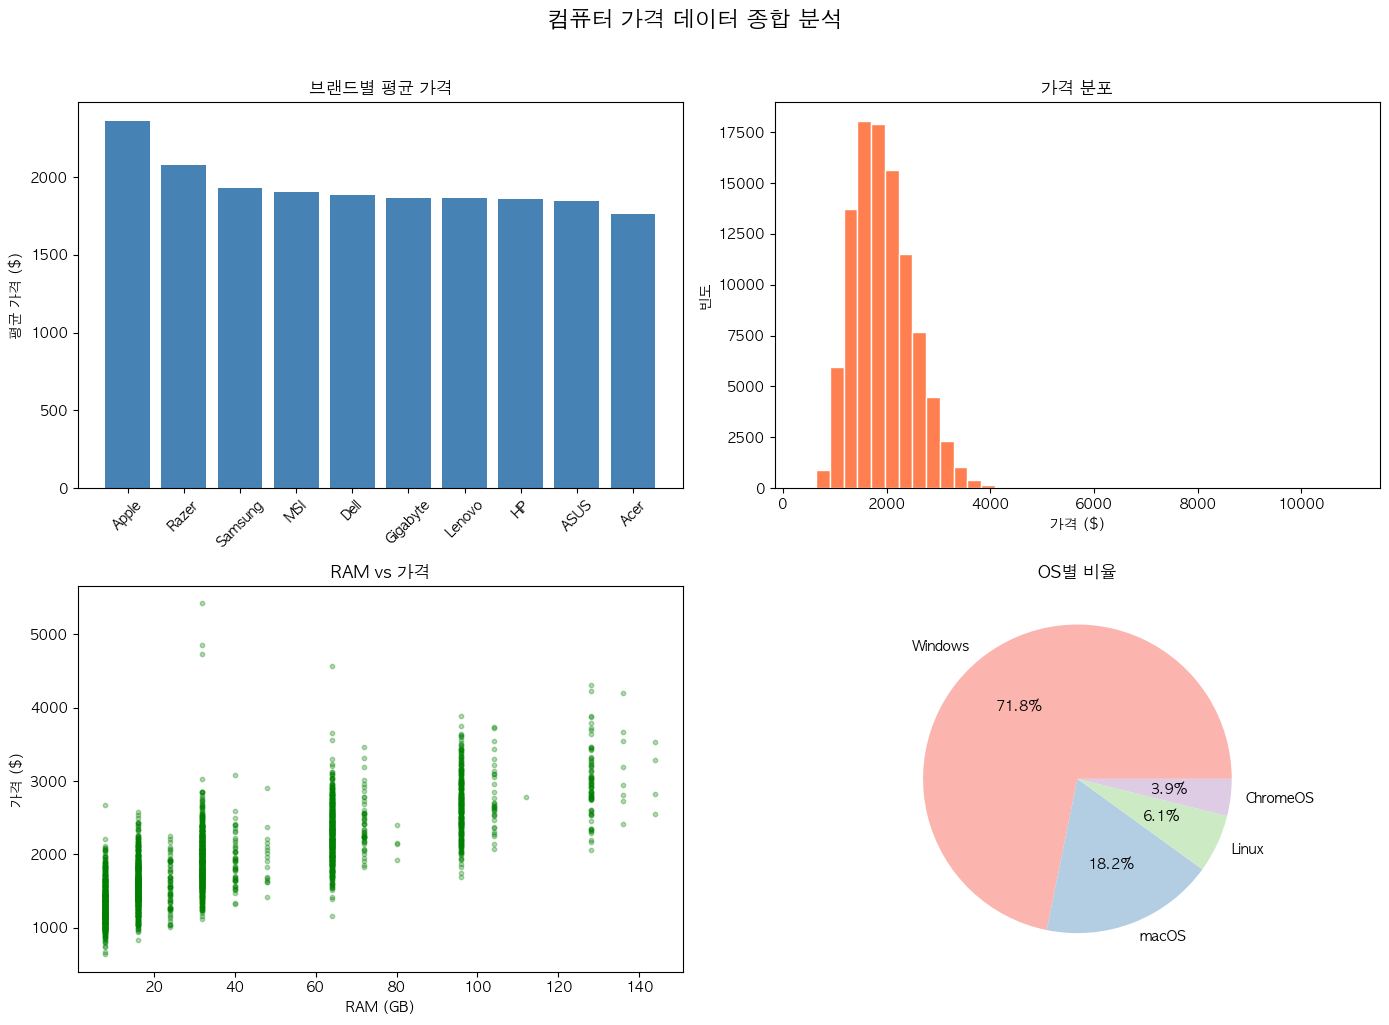

In [15]:
# 2×2 서브플롯 - 컴퓨터 데이터 4가지 관점
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# [0,0] 브랜드별 평균 가격 (막대)
brand_price = df_comp.groupby('brand')['price'].mean().sort_values(ascending=False)
axes[0, 0].bar(brand_price.index, brand_price.values, color='steelblue')
axes[0, 0].set_title('브랜드별 평균 가격', fontweight='bold')
axes[0, 0].set_ylabel('평균 가격 ($)')
axes[0, 0].tick_params(axis='x', rotation=45)

# [0,1] 가격 분포 (히스토그램)
axes[0, 1].hist(df_comp['price'], bins=40, color='coral', edgecolor='white')
axes[0, 1].set_title('가격 분포', fontweight='bold')
axes[0, 1].set_xlabel('가격 ($)')
axes[0, 1].set_ylabel('빈도')

# [1,0] RAM vs 가격 (산점도)
sample = df_comp.sample(3000, random_state=42)
axes[1, 0].scatter(sample['ram_gb'], sample['price'],
                    alpha=0.3, s=10, color='green')
axes[1, 0].set_title('RAM vs 가격', fontweight='bold')
axes[1, 0].set_xlabel('RAM (GB)')
axes[1, 0].set_ylabel('가격 ($)')

# [1,1] OS별 비율 (파이)
os_counts = df_comp['os'].value_counts()
axes[1, 1].pie(os_counts.values, labels=os_counts.index,
               autopct='%1.1f%%', colors=plt.cm.Pastel1.colors)
axes[1, 1].set_title('OS별 비율', fontweight='bold')

fig.suptitle('컴퓨터 가격 데이터 종합 분석', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 🕐 2교시: Seaborn 기초~중급
---

> **Seaborn**은 Matplotlib 위에 구축된 통계 시각화 라이브러리입니다.
> - 적은 코드로 아름다운 통계 차트를 만들 수 있음
> - DataFrame을 직접 전달하여 컬럼명으로 바로 시각화
> - 자동으로 그룹별 색상 분리, 통계 요약 등을 수행

## 2-1. countplot() — 범주별 빈도 시각화

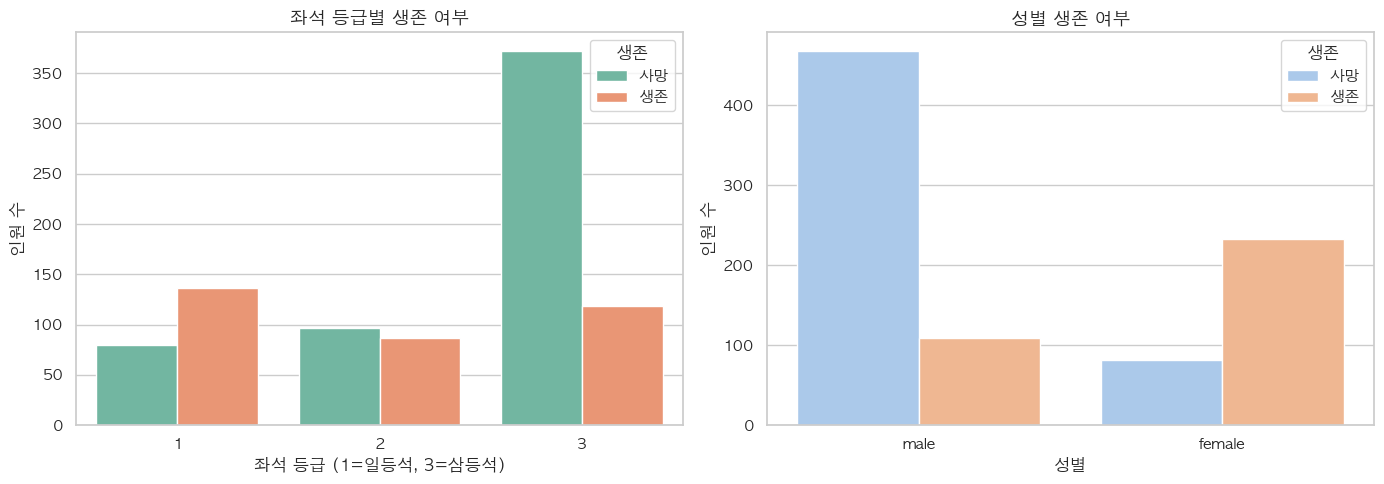

In [16]:
# Seaborn 스타일 설정
sns.set_theme(style='whitegrid', font='AppleGothic')   # 배경 스타일 + 한글 폰트
plt.rcParams['axes.unicode_minus'] = False

# countplot - 범주별 빈도 (막대 그래프의 seaborn 버전)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 좌측: 타이타닉 - 좌석 등급별 생존/사망 비교
sns.countplot(data=df_titanic, x='pclass', hue='survived',
              palette='Set2', ax=axes[0])
axes[0].set_title('좌석 등급별 생존 여부', fontsize=13, fontweight='bold')
axes[0].set_xlabel('좌석 등급 (1=일등석, 3=삼등석)')
axes[0].set_ylabel('인원 수')
axes[0].legend(title='생존', labels=['사망', '생존'])

# 우측: 타이타닉 - 성별 × 생존 여부
sns.countplot(data=df_titanic, x='sex', hue='survived',
              palette='pastel', ax=axes[1])
axes[1].set_title('성별 생존 여부', fontsize=13, fontweight='bold')
axes[1].set_xlabel('성별')
axes[1].set_ylabel('인원 수')
axes[1].legend(title='생존', labels=['사망', '생존'])

plt.tight_layout()
plt.show()

## 2-2. histplot() & kdeplot() — 분포 시각화

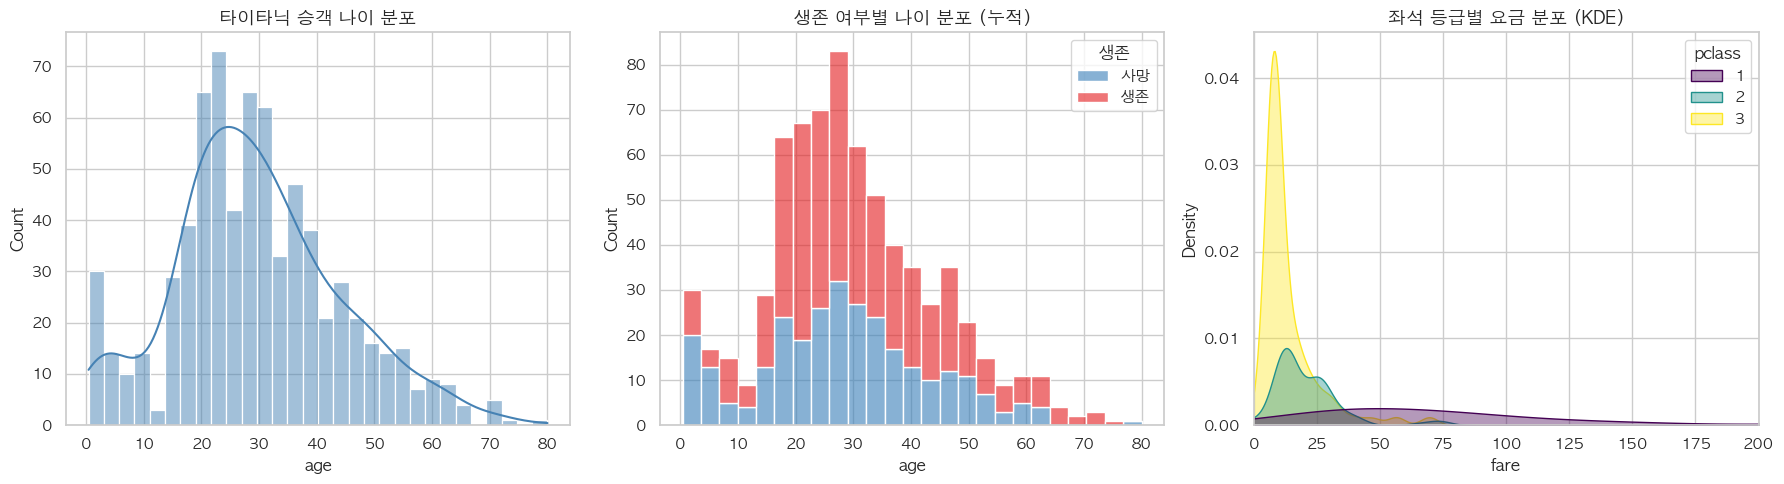

In [17]:
# histplot + kdeplot - 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 좌측: histplot - 히스토그램 + KDE 곡선 동시 표시
sns.histplot(data=df_titanic, x='age', bins=30, kde=True,
             color='steelblue', ax=axes[0])
axes[0].set_title('타이타닉 승객 나이 분포', fontsize=13, fontweight='bold')

# 중앙: histplot with hue - 그룹별 분포 비교
sns.histplot(data=df_titanic, x='age', hue='survived',
             bins=25, alpha=0.6, multiple='stack',     # 누적 히스토그램
             palette='Set1', ax=axes[1])
axes[1].set_title('생존 여부별 나이 분포 (누적)', fontsize=13, fontweight='bold')
axes[1].legend(title='생존', labels=['사망', '생존'])

# 우측: kdeplot - 커널 밀도 추정 (부드러운 분포 곡선)
sns.kdeplot(data=df_titanic, x='fare', hue='pclass',
            fill=True, alpha=0.4,                       # 곡선 아래 채우기
            palette='viridis', ax=axes[2])
axes[2].set_title('좌석 등급별 요금 분포 (KDE)', fontsize=13, fontweight='bold')
axes[2].set_xlim(0, 200)                                # x축 범위 제한

plt.tight_layout()
plt.show()

## 2-3. boxplot() & violinplot() — 분포 + 이상치 시각화

> - **박스플롯**: 중앙값, 사분위수, 이상치를 한눈에 파악
> - **바이올린플롯**: 박스플롯 + KDE를 결합하여 분포의 형태까지 표현

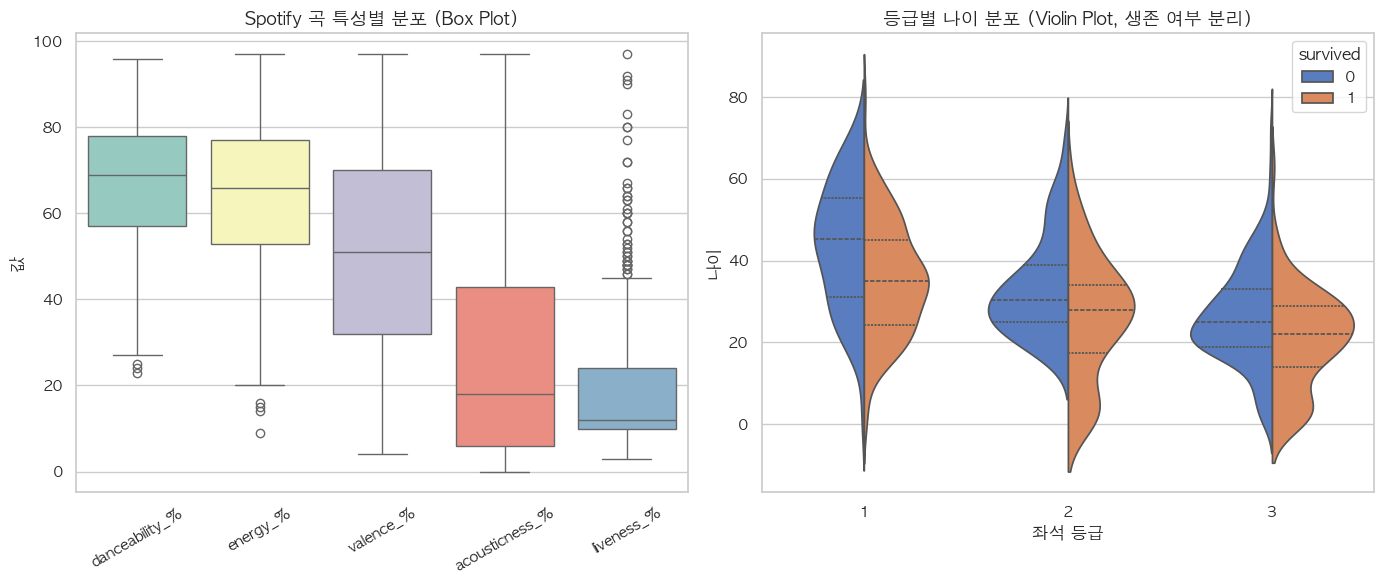

In [18]:
# 박스플롯 vs 바이올린플롯 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 좌측: 박스플롯 - Spotify 곡의 장르 특성별 분포
spotify_features = df_spotify[['danceability_%', 'energy_%', 'valence_%',
                                'acousticness_%', 'liveness_%']].melt(
    var_name='특성', value_name='값')
sns.boxplot(data=spotify_features, x='특성', y='값',
            palette='Set3', ax=axes[0])
axes[0].set_title('Spotify 곡 특성별 분포 (Box Plot)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# 우측: 바이올린플롯 - 타이타닉 좌석 등급별 나이 분포
sns.violinplot(data=df_titanic, x='pclass', y='age', hue='survived',
               split=True,                               # hue 기준 좌우 분리
               palette='muted',
               inner='quart',                             # 내부에 사분위수 표시
               ax=axes[1])
axes[1].set_title('등급별 나이 분포 (Violin Plot, 생존 여부 분리)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('좌석 등급')
axes[1].set_ylabel('나이')

plt.tight_layout()
plt.show()

## 2-4. barplot() & stripplot() — 통계 막대 + 개별 데이터 포인트

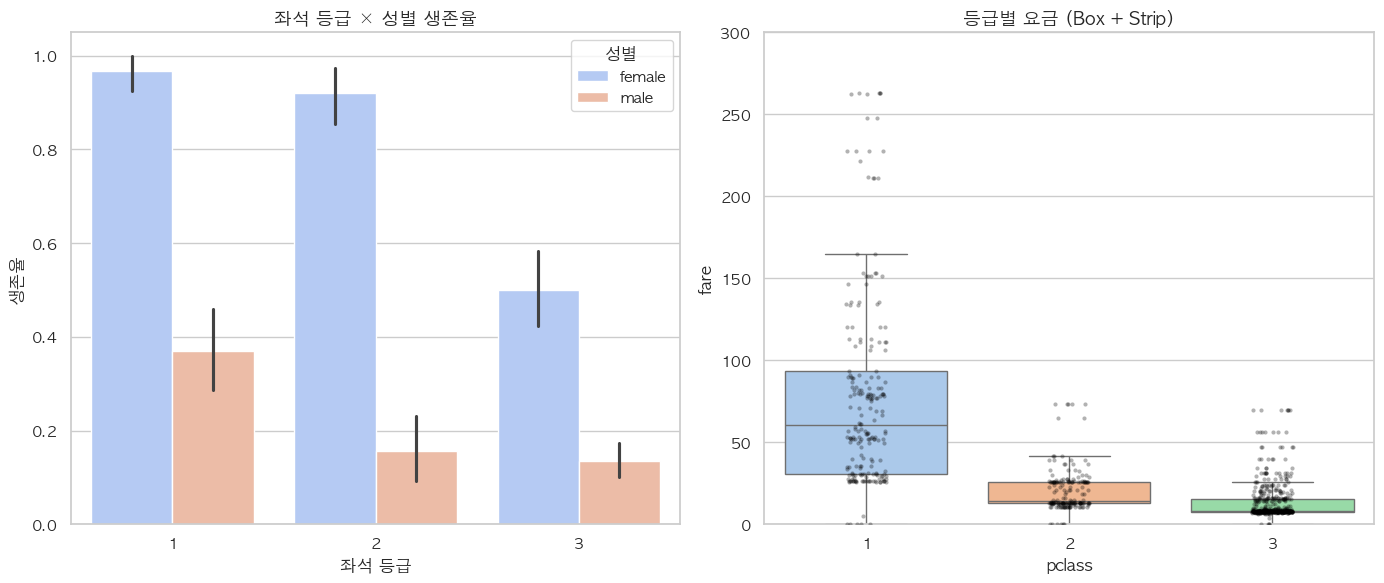

In [19]:
# barplot - 자동으로 평균 + 신뢰구간 표시
# stripplot - 개별 데이터 포인트를 점으로 표시

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 좌측: barplot - 타이타닉 성별/등급별 생존율
sns.barplot(data=df_titanic, x='pclass', y='survived', hue='sex',
            palette='coolwarm', ci=95,                   # 95% 신뢰구간
            ax=axes[0])
axes[0].set_title('좌석 등급 × 성별 생존율', fontsize=13, fontweight='bold')
axes[0].set_xlabel('좌석 등급')
axes[0].set_ylabel('생존율')
axes[0].legend(title='성별')

# 우측: boxplot + stripplot 결합 - 개별 데이터를 점으로 겹쳐 표시
sns.boxplot(data=df_titanic, x='pclass', y='fare',
            palette='pastel', ax=axes[1],
            fliersize=0)                                  # 이상치 점 숨기기 (strip으로 대체)
sns.stripplot(data=df_titanic, x='pclass', y='fare',
              color='black', alpha=0.3, size=3,
              jitter=True,                                # 수평 흩뿌리기
              ax=axes[1])
axes[1].set_title('등급별 요금 (Box + Strip)', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 300)                                  # y축 제한

plt.tight_layout()
plt.show()

## 2-5. heatmap() — 히트맵 (상관관계, 교차표)

> 2차원 데이터를 **색상의 강도**로 표현합니다. 상관관계 행렬이나 교차표 시각화에 매우 유용합니다.

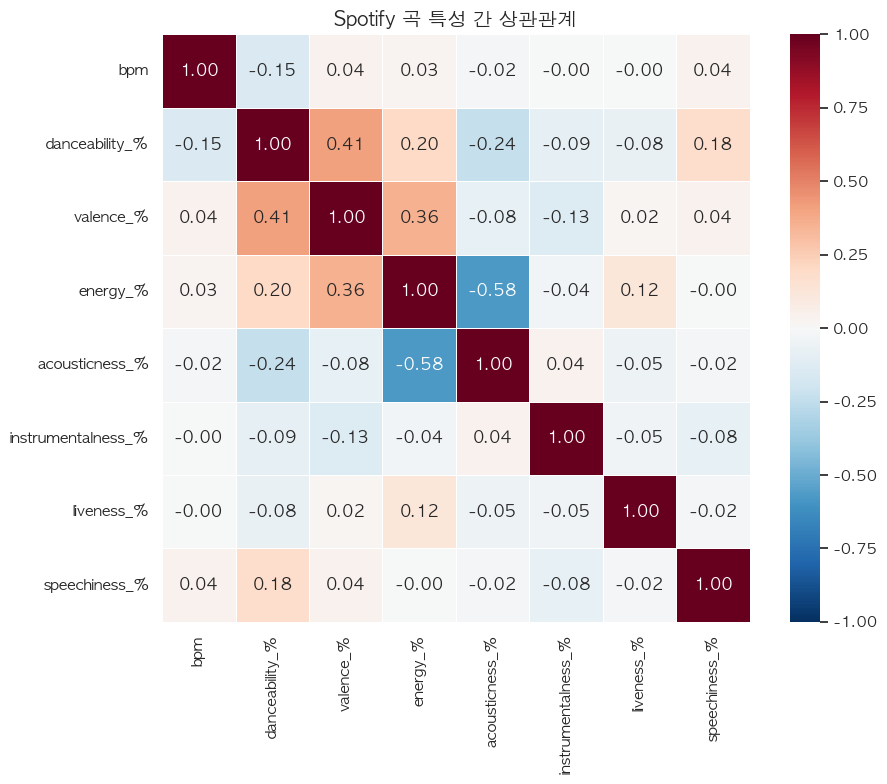

In [20]:
# 상관관계 히트맵 - Spotify 곡 특성 간 상관관계
spotify_nums = df_spotify[['bpm', 'danceability_%', 'valence_%', 'energy_%',
                            'acousticness_%', 'instrumentalness_%',
                            'liveness_%', 'speechiness_%']]
corr = spotify_nums.corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(corr,
            annot=True,                    # 셀에 숫자 표시
            fmt='.2f',                     # 소수점 2자리
            cmap='RdBu_r',                 # 빨강-파랑 컬러맵 (반전)
            center=0,                      # 0을 중심으로 색상 대칭
            vmin=-1, vmax=1,               # 색상 범위
            square=True,                   # 정사각형 셀
            linewidths=0.5,                # 셀 간 구분선
            ax=ax)

ax.set_title('Spotify 곡 특성 간 상관관계', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

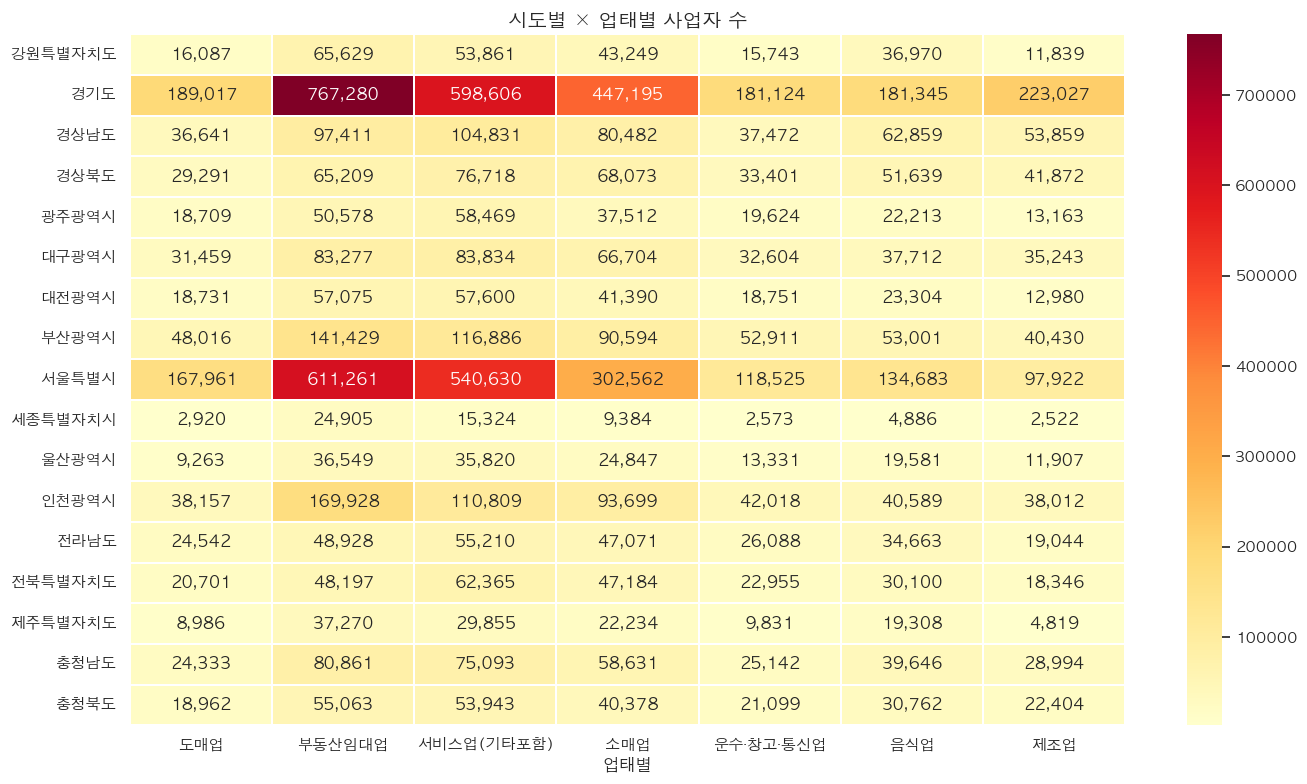

In [21]:
# 교차표 히트맵 - 사업자현황 데이터
# 시도별 × 업태별 사업자 수 히트맵

# 상위 7개 업태만 선택
top_types = df_biz.groupby('업태별')['(전체)당월'].sum().nlargest(7).index
biz_filtered = df_biz[df_biz['업태별'].isin(top_types)]

# 시도별 업태별 합계 피벗
biz_pivot = biz_filtered.pivot_table(
    values='(전체)당월', index='시도', columns='업태별', aggfunc='sum', fill_value=0)

fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(biz_pivot,
            annot=True, fmt=',',           # 천 단위 콤마
            cmap='YlOrRd',                 # 노랑→주황→빨강
            linewidths=0.3,
            ax=ax)

ax.set_title('시도별 × 업태별 사업자 수', fontsize=14, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 2-6. scatterplot() & regplot() — 관계 시각화

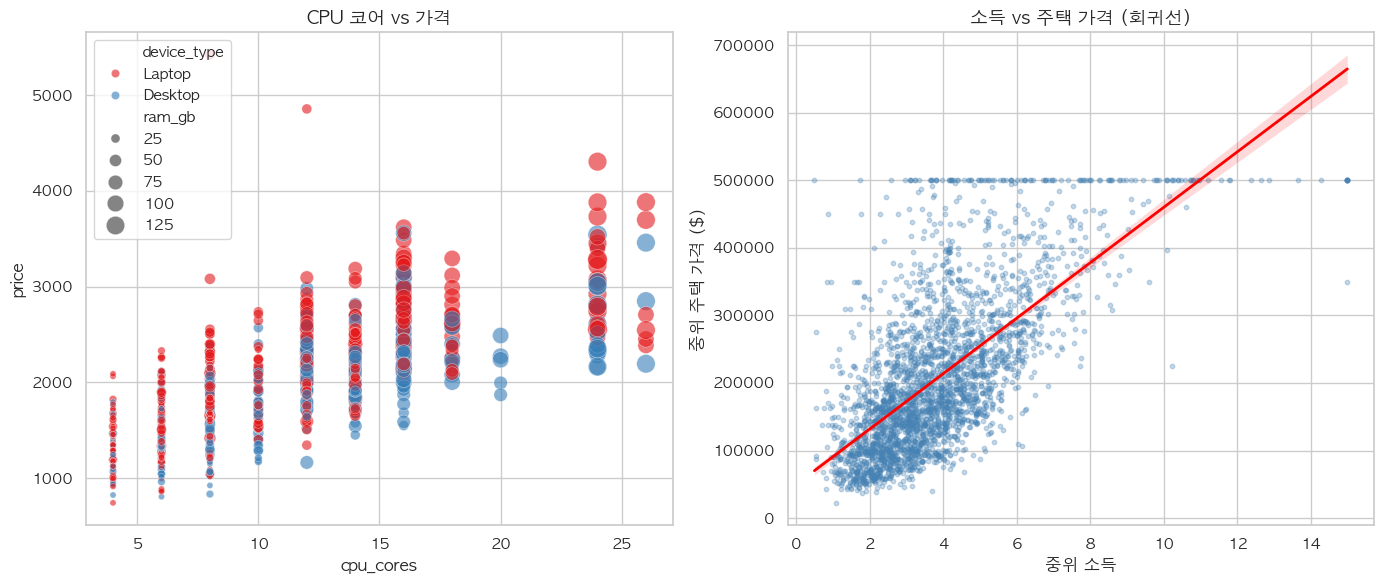

In [22]:
# scatterplot + regplot - 관계 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 좌측: scatterplot - hue, size, style 다차원 표현
sample = df_comp.sample(1000, random_state=42)
sns.scatterplot(data=sample, x='cpu_cores', y='price',
                hue='device_type',                       # 색상 = 기기유형
                size='ram_gb',                            # 크기 = RAM
                sizes=(20, 200),                          # 크기 범위
                alpha=0.6,
                palette='Set1',
                ax=axes[0])
axes[0].set_title('CPU 코어 vs 가격', fontsize=13, fontweight='bold')

# 우측: regplot - 산점도 + 회귀선 (추세선)
sns.regplot(data=df_housing, x='median_income', y='median_house_value',
            scatter_kws={'alpha': 0.3, 's': 10, 'color': 'steelblue'},
            line_kws={'color': 'red', 'linewidth': 2},
            ax=axes[1])
axes[1].set_title('소득 vs 주택 가격 (회귀선)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('중위 소득')
axes[1].set_ylabel('중위 주택 가격 ($)')

plt.tight_layout()
plt.show()

## 2-7. pairplot() — 변수 쌍별 관계 한눈에 보기

> `pairplot()`은 여러 수치형 변수의 **모든 쌍별 조합**을 자동으로 그려줍니다.
> - 대각선: 각 변수의 분포 (히스토그램/KDE)
> - 비대각선: 변수 쌍의 산점도

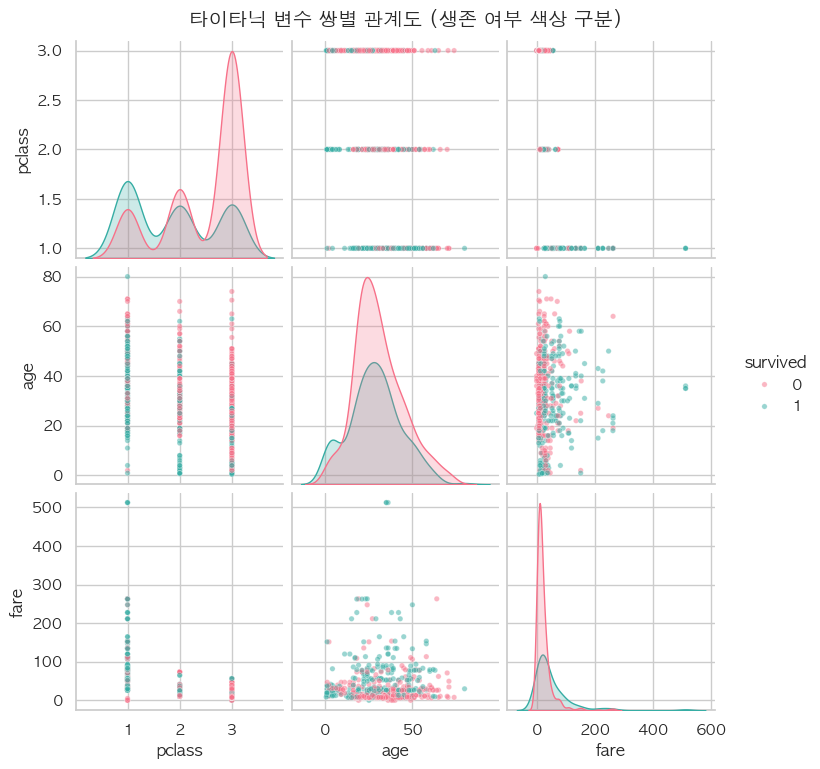

In [23]:
# pairplot - 타이타닉 데이터의 주요 변수 관계
# 변수가 너무 많으면 느려지므로 핵심 변수만 선택
titanic_sub = df_titanic[['survived', 'pclass', 'age', 'fare']].dropna()

sns.pairplot(titanic_sub,
             hue='survived',                  # 생존 여부로 색상 구분
             palette='husl',
             diag_kind='kde',                  # 대각선: KDE
             plot_kws={'alpha': 0.5, 's': 15},
             height=2.5)

plt.suptitle('타이타닉 변수 쌍별 관계도 (생존 여부 색상 구분)',
             fontsize=14, fontweight='bold', y=1.02)
plt.show()

# 🕐 3교시: 고급 시각화 + 실전 대시보드 + 연습문제
---
## 3-1. 고급 스타일링 — 주석, 텍스트, 화살표

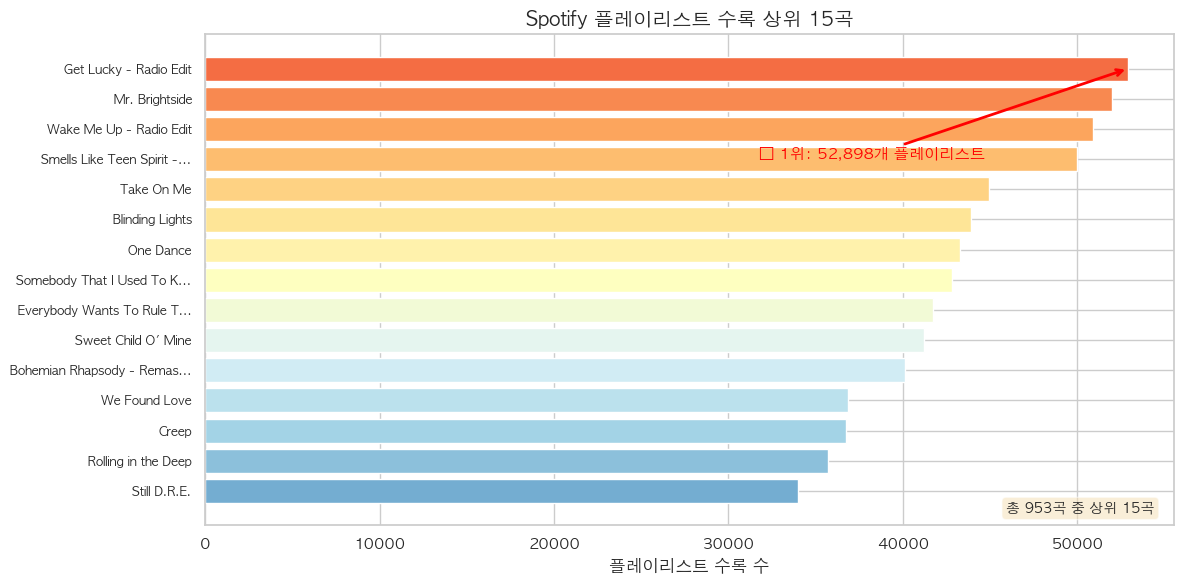

In [24]:
# 주석(annotate)과 텍스트 추가
# Spotify: 가장 많이 플레이리스트에 포함된 상위 곡

top_songs = df_spotify.nlargest(15, 'in_spotify_playlists')

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(range(len(top_songs)), top_songs['in_spotify_playlists'],
               color=plt.cm.RdYlBu(np.linspace(0.2, 0.8, len(top_songs))))

# y축에 곡 이름 표시
ax.set_yticks(range(len(top_songs)))
ax.set_yticklabels([f"{name[:25]}..." if len(name) > 25 else name
                     for name in top_songs['track_name']], fontsize=9)

# 1위 곡에 화살표 주석 추가
ax.annotate(f"🏆 1위: {top_songs.iloc[0]['in_spotify_playlists']:,}개 플레이리스트",
            xy=(top_songs.iloc[0]['in_spotify_playlists'], 0),  # 화살표 끝 좌표
            xytext=(top_songs.iloc[0]['in_spotify_playlists'] * 0.6, 3),  # 텍스트 위치
            fontsize=11, fontweight='bold', color='red',
            arrowprops=dict(arrowstyle='->', color='red', lw=2))

# 텍스트 박스 추가
textstr = f'총 {len(df_spotify):,}곡 중 상위 15곡'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.98, 0.02, textstr, transform=ax.transAxes,
        fontsize=10, verticalalignment='bottom', horizontalalignment='right',
        bbox=props)

ax.set_title('Spotify 플레이리스트 수록 상위 15곡', fontsize=14, fontweight='bold')
ax.set_xlabel('플레이리스트 수록 수')
ax.invert_yaxis()                                     # 1위를 맨 위에
plt.tight_layout()
plt.show()

## 3-2. 지하철 혼잡도 — 시간대별 라인 히트맵

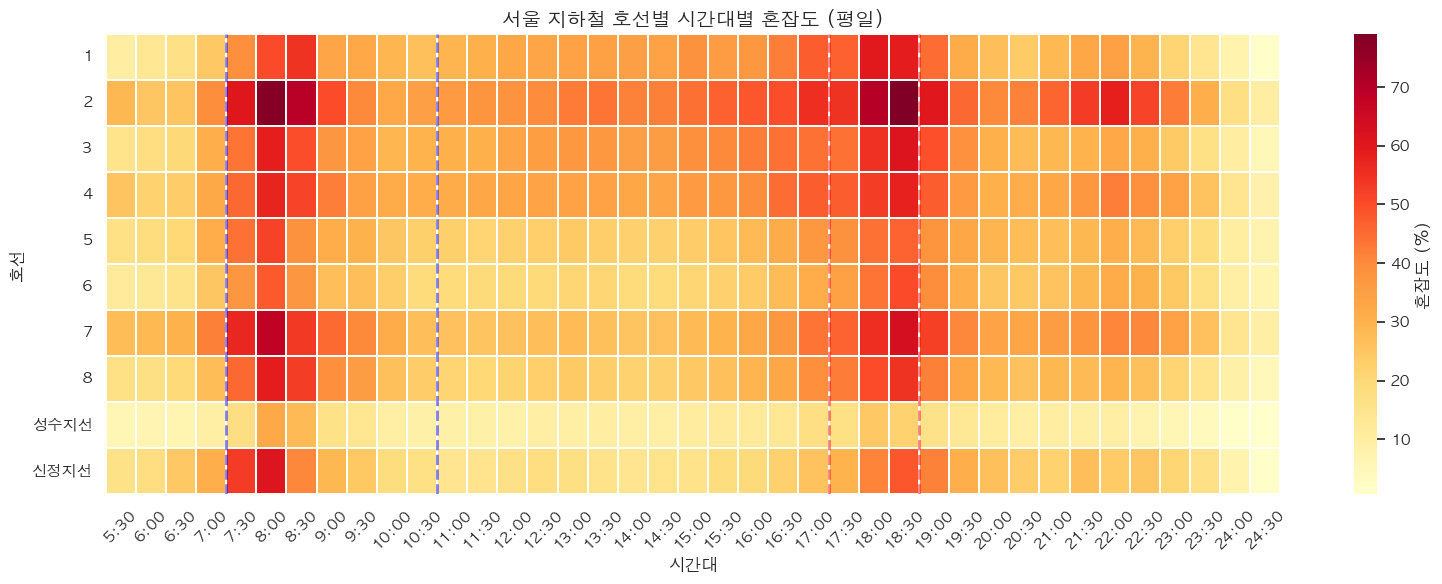

In [25]:
# 지하철 혼잡도 히트맵 - 호선별 시간대별 평균 혼잡도
# 시간대 컬럼만 추출 (5:30~24:30)
time_cols = [c for c in df_subway.columns if '~' in c]

# 평일 데이터만 선택, 호선별 시간대 평균
subway_weekday = df_subway[df_subway['요일'] == '평일']
line_time_avg = subway_weekday.groupby('호선')[time_cols].mean()

# 시간대 라벨 정리 (5:30~ (%) → 5:30)
clean_labels = [c.replace('~ (%)', '').strip() for c in time_cols]

fig, ax = plt.subplots(figsize=(16, 6))

sns.heatmap(line_time_avg,
            cmap='YlOrRd',
            xticklabels=clean_labels,
            annot=False,                       # 셀이 많으므로 숫자 생략
            linewidths=0.1,
            cbar_kws={'label': '혼잡도 (%)'},
            ax=ax)

ax.set_title('서울 지하철 호선별 시간대별 혼잡도 (평일)', fontsize=14, fontweight='bold')
ax.set_xlabel('시간대', fontsize=12)
ax.set_ylabel('호선', fontsize=12)
ax.tick_params(axis='x', rotation=45)

# 출퇴근 시간대 강조 표시
ax.axvline(x=4, color='blue', linewidth=2, linestyle='--', alpha=0.5)   # 7:30 (출근)
ax.axvline(x=11, color='blue', linewidth=2, linestyle='--', alpha=0.5)  # 11:00
ax.axvline(x=24, color='red', linewidth=2, linestyle='--', alpha=0.5)   # 17:30 (퇴근)
ax.axvline(x=27, color='red', linewidth=2, linestyle='--', alpha=0.5)   # 19:00

plt.tight_layout()
plt.show()

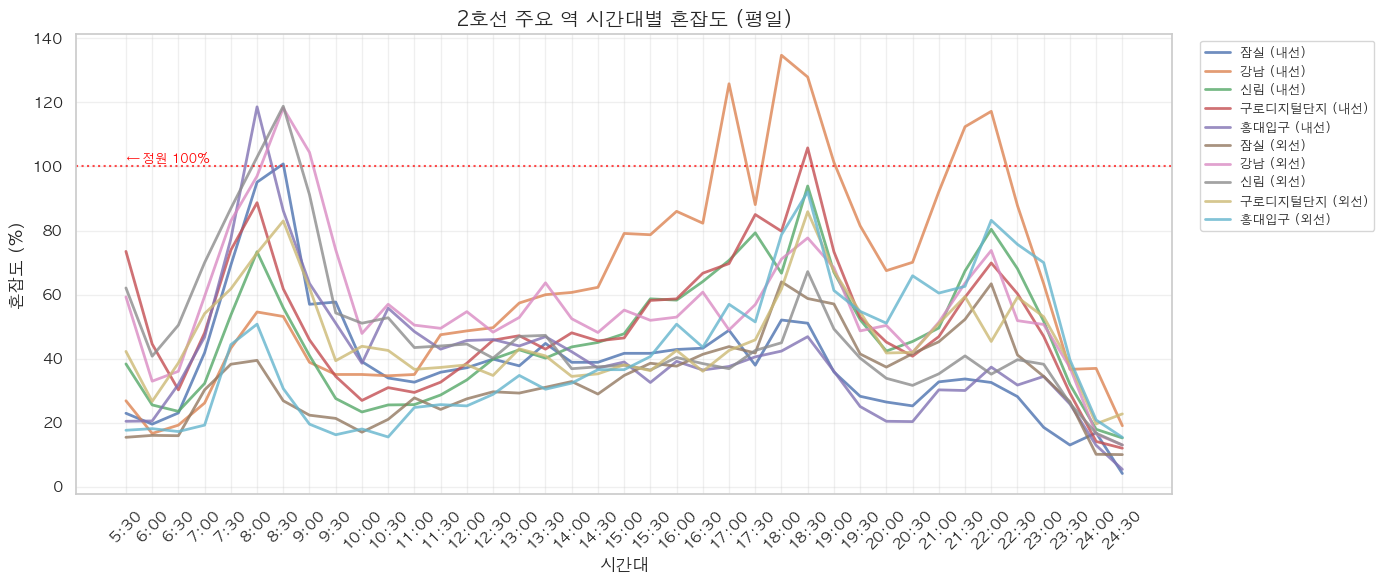

In [26]:
# 지하철 혼잡도 - 2호선 주요 역 시간대별 혼잡도 선 그래프
# 2호선 평일, 주요 역만 선택
line2 = df_subway[(df_subway['호선'] == '2') & (df_subway['요일'] == '평일')]
major_stations = ['강남', '잠실', '홍대입구', '신림', '구로디지털단지']
line2_major = line2[line2['역명'].isin(major_stations)]

fig, ax = plt.subplots(figsize=(14, 6))

# 시간대별 혼잡도 (각 역 = 하나의 선)
x_labels = [c.replace('~ (%)', '').strip() for c in time_cols]
for _, row in line2_major.iterrows():
    ax.plot(x_labels, row[time_cols].values,
            marker='', linewidth=2, alpha=0.8, label=f"{row['역명']} ({row['방향']})")

ax.set_title('2호선 주요 역 시간대별 혼잡도 (평일)', fontsize=14, fontweight='bold')
ax.set_xlabel('시간대', fontsize=12)
ax.set_ylabel('혼잡도 (%)', fontsize=12)
ax.tick_params(axis='x', rotation=45)

# 100% 기준선 (정원 초과)
ax.axhline(y=100, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(0, 101, '← 정원 100%', fontsize=9, color='red')

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3-3. 실전 대시보드 — 여러 차트를 하나의 화면에 구성

> 실무에서는 관련 차트 여러 개를 하나의 화면(대시보드)에 배치합니다.
> `gridspec`이나 `subplot2grid`로 불균등한 레이아웃도 가능합니다.

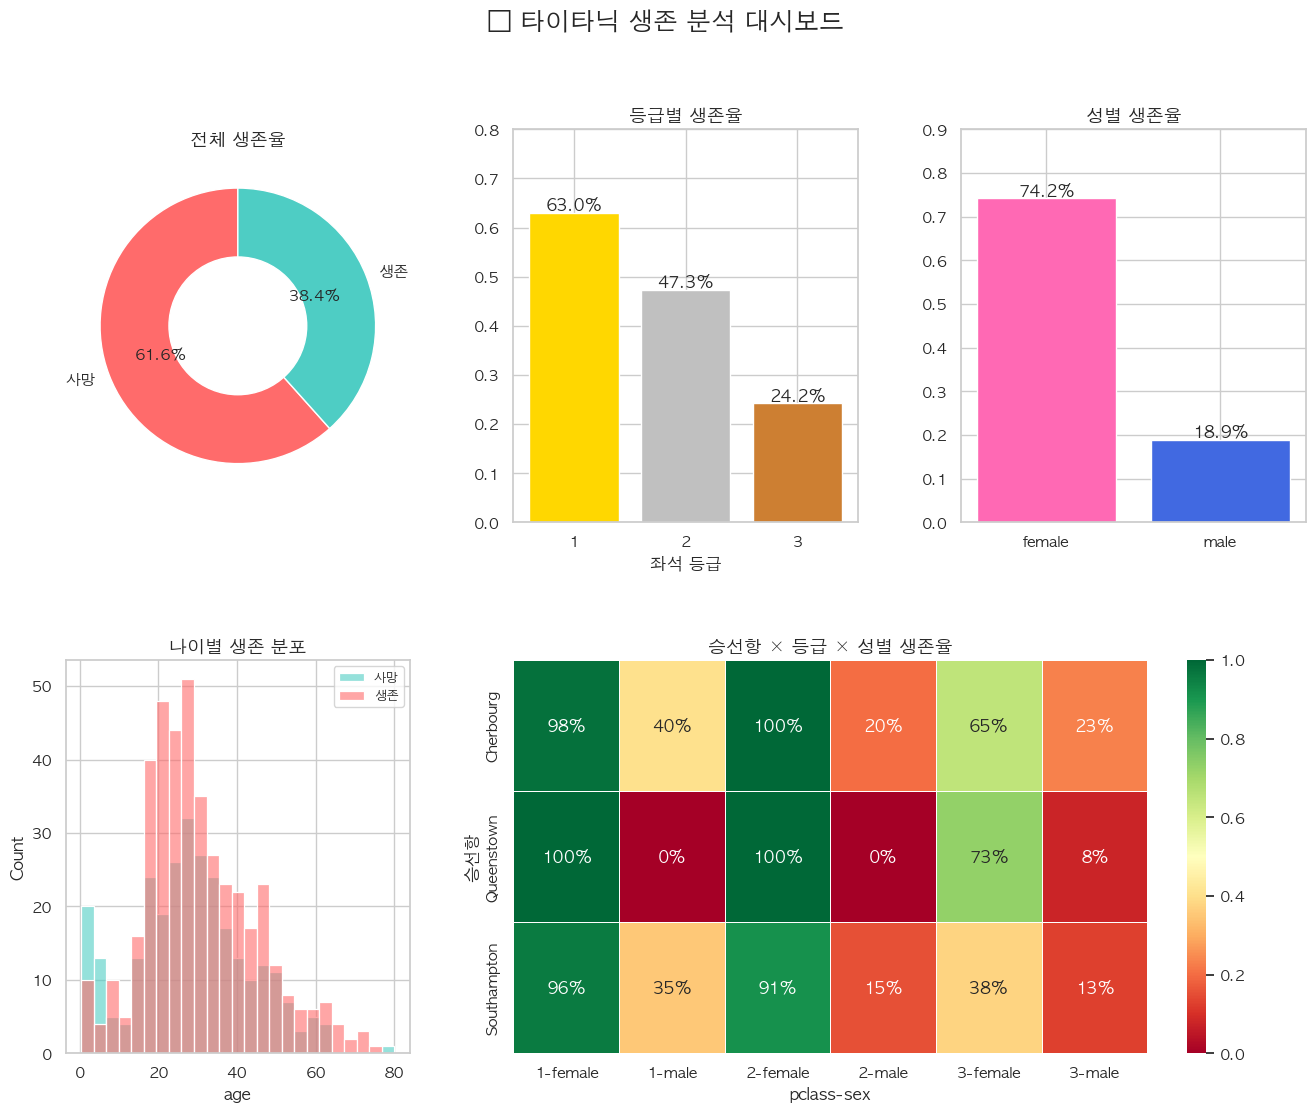

In [27]:
# 실전 대시보드 1: 타이타닉 생존 분석 대시보드
fig = plt.figure(figsize=(16, 12))
fig.suptitle('🚢 타이타닉 생존 분석 대시보드', fontsize=18, fontweight='bold', y=0.98)

# 불균등 레이아웃: gridspec 사용
from matplotlib.gridspec import GridSpec
gs = GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

# [상단 좌] 전체 생존율 - 도넛 차트
ax1 = fig.add_subplot(gs[0, 0])
survived_counts = df_titanic['survived'].value_counts()
ax1.pie(survived_counts, labels=['사망', '생존'], autopct='%1.1f%%',
        colors=['#FF6B6B', '#4ECDC4'], startangle=90, textprops={'fontsize': 11})
centre = plt.Circle((0, 0), 0.5, fc='white')
ax1.add_artist(centre)
ax1.set_title('전체 생존율', fontsize=13, fontweight='bold')

# [상단 중] 등급별 생존율 - 막대 그래프
ax2 = fig.add_subplot(gs[0, 1])
survival_rate = df_titanic.groupby('pclass')['survived'].mean()
bars = ax2.bar(survival_rate.index.astype(str), survival_rate.values,
               color=['#FFD700', '#C0C0C0', '#CD7F32'])
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{bar.get_height():.1%}', ha='center', va='bottom', fontweight='bold')
ax2.set_title('등급별 생존율', fontsize=13, fontweight='bold')
ax2.set_xlabel('좌석 등급')
ax2.set_ylim(0, 0.8)

# [상단 우] 성별 생존율 - 막대 그래프
ax3 = fig.add_subplot(gs[0, 2])
sex_survival = df_titanic.groupby('sex')['survived'].mean()
bars = ax3.bar(sex_survival.index, sex_survival.values,
               color=['#FF69B4', '#4169E1'])
for bar in bars:
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{bar.get_height():.1%}', ha='center', va='bottom', fontweight='bold')
ax3.set_title('성별 생존율', fontsize=13, fontweight='bold')
ax3.set_ylim(0, 0.9)

# [하단 좌] 나이 분포 - 히스토그램
ax4 = fig.add_subplot(gs[1, 0])
sns.histplot(data=df_titanic, x='age', hue='survived', bins=25,
             alpha=0.6, palette=['#FF6B6B', '#4ECDC4'], ax=ax4)
ax4.set_title('나이별 생존 분포', fontsize=13, fontweight='bold')
ax4.legend(labels=['사망', '생존'], fontsize=9)

# [하단 중+우] 등급×성별 생존율 히트맵 (2칸 차지)
ax5 = fig.add_subplot(gs[1, 1:])
pivot_survival = df_titanic.pivot_table(values='survived', index='embark_town',
                                         columns=['pclass', 'sex'], aggfunc='mean')
sns.heatmap(pivot_survival, annot=True, fmt='.0%', cmap='RdYlGn',
            linewidths=0.5, ax=ax5, vmin=0, vmax=1)
ax5.set_title('승선항 × 등급 × 성별 생존율', fontsize=13, fontweight='bold')
ax5.set_ylabel('승선항')

plt.show()

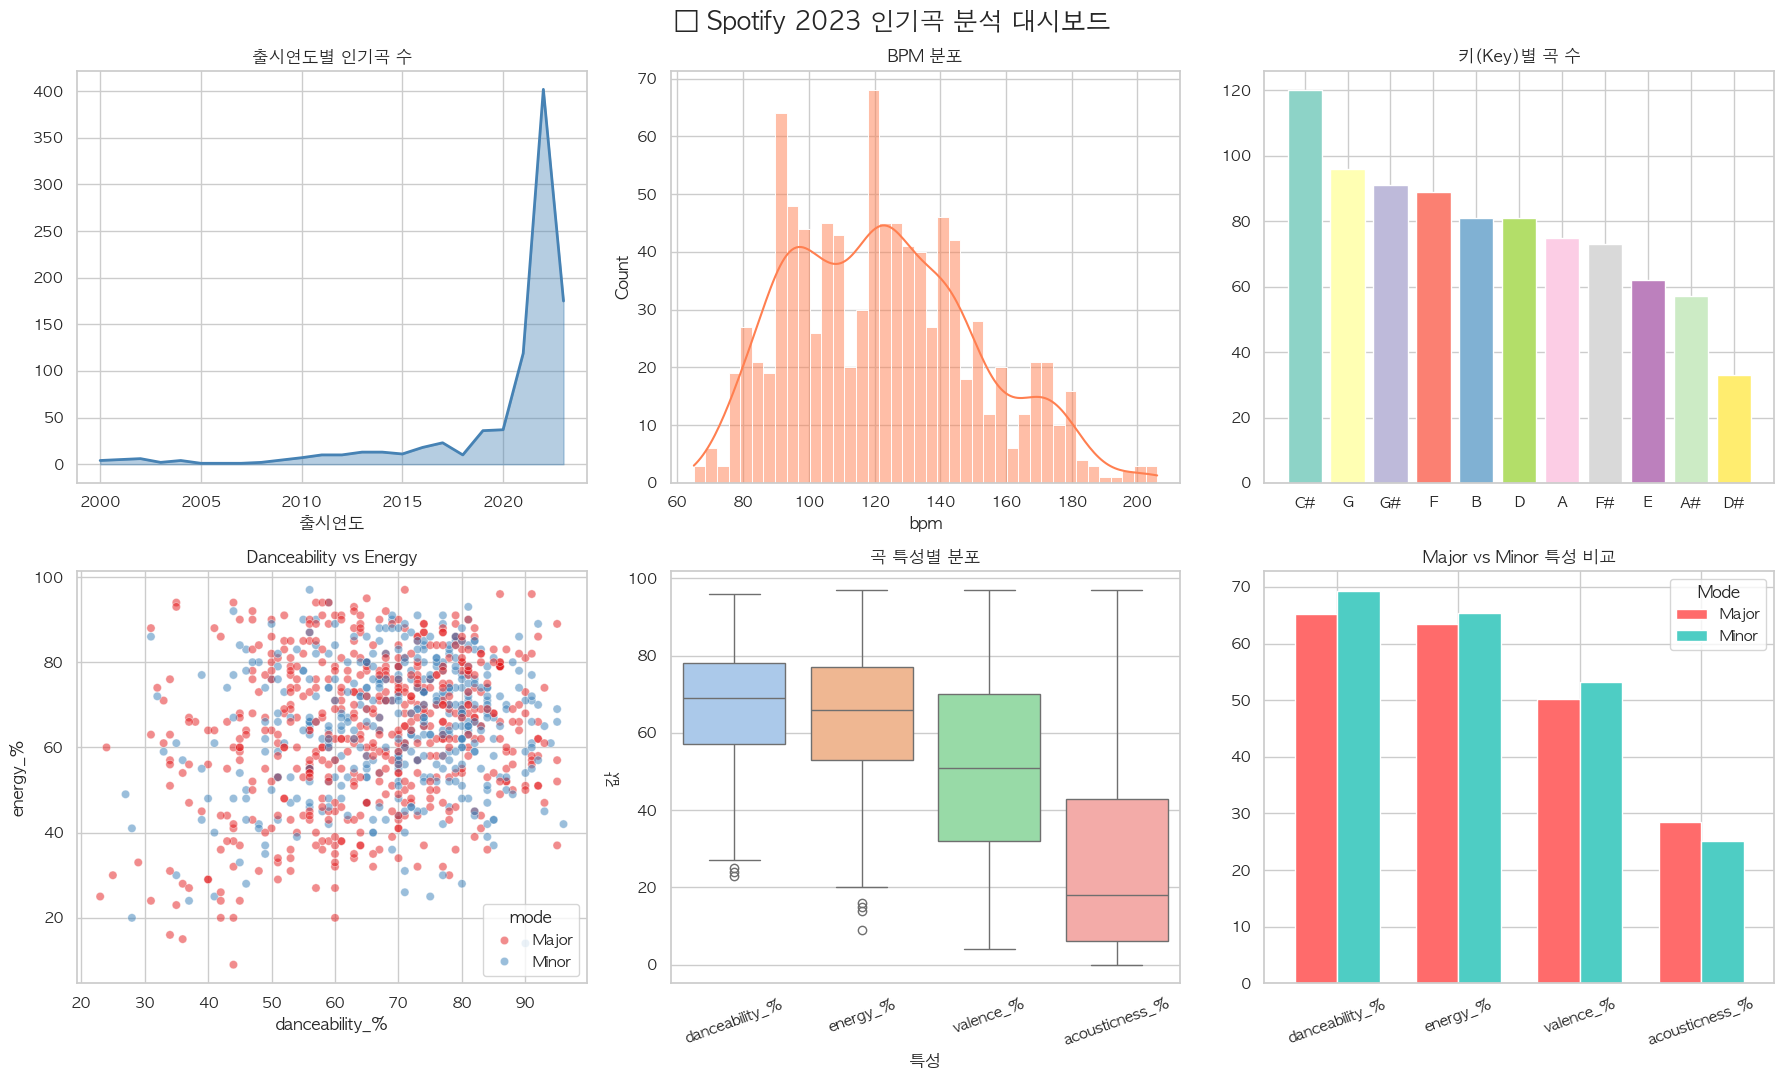

In [28]:
# 실전 대시보드 2: Spotify 음악 분석 대시보드
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('🎵 Spotify 2023 인기곡 분석 대시보드', fontsize=18, fontweight='bold')

# [0,0] 출시연도별 곡 수
year_counts = df_spotify['released_year'].value_counts().sort_index()
year_counts = year_counts[year_counts.index >= 2000]      # 2000년 이후만
axes[0, 0].fill_between(year_counts.index, year_counts.values,
                          alpha=0.4, color='steelblue')
axes[0, 0].plot(year_counts.index, year_counts.values, color='steelblue', linewidth=2)
axes[0, 0].set_title('출시연도별 인기곡 수', fontweight='bold')
axes[0, 0].set_xlabel('출시연도')

# [0,1] BPM 분포
sns.histplot(data=df_spotify, x='bpm', bins=40, kde=True,
             color='coral', ax=axes[0, 1])
axes[0, 1].set_title('BPM 분포', fontweight='bold')

# [0,2] 키(Key)별 곡 수
key_counts = df_spotify['key'].value_counts()
axes[0, 2].bar(key_counts.index, key_counts.values,
               color=plt.cm.Set3(np.linspace(0, 1, len(key_counts))))
axes[0, 2].set_title('키(Key)별 곡 수', fontweight='bold')

# [1,0] Danceability vs Energy
sns.scatterplot(data=df_spotify, x='danceability_%', y='energy_%',
                hue='mode', alpha=0.5, palette='Set1', ax=axes[1, 0])
axes[1, 0].set_title('Danceability vs Energy', fontweight='bold')

# [1,1] 특성별 분포 박스플롯
features_melt = df_spotify[['danceability_%', 'energy_%', 'valence_%',
                             'acousticness_%']].melt(var_name='특성', value_name='값')
sns.boxplot(data=features_melt, x='특성', y='값', palette='pastel', ax=axes[1, 1])
axes[1, 1].set_title('곡 특성별 분포', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=20)

# [1,2] Major vs Minor 모드별 특성 비교
mode_avg = df_spotify.groupby('mode')[['danceability_%', 'energy_%',
                                        'valence_%', 'acousticness_%']].mean()
mode_avg.T.plot(kind='bar', ax=axes[1, 2], color=['#FF6B6B', '#4ECDC4'], width=0.7)
axes[1, 2].set_title('Major vs Minor 특성 비교', fontweight='bold')
axes[1, 2].tick_params(axis='x', rotation=20)
axes[1, 2].legend(title='Mode')

plt.tight_layout()
plt.show()

## 3-4. 다양한 스타일 테마 비교

> Seaborn과 Matplotlib은 다양한 내장 스타일을 제공합니다.

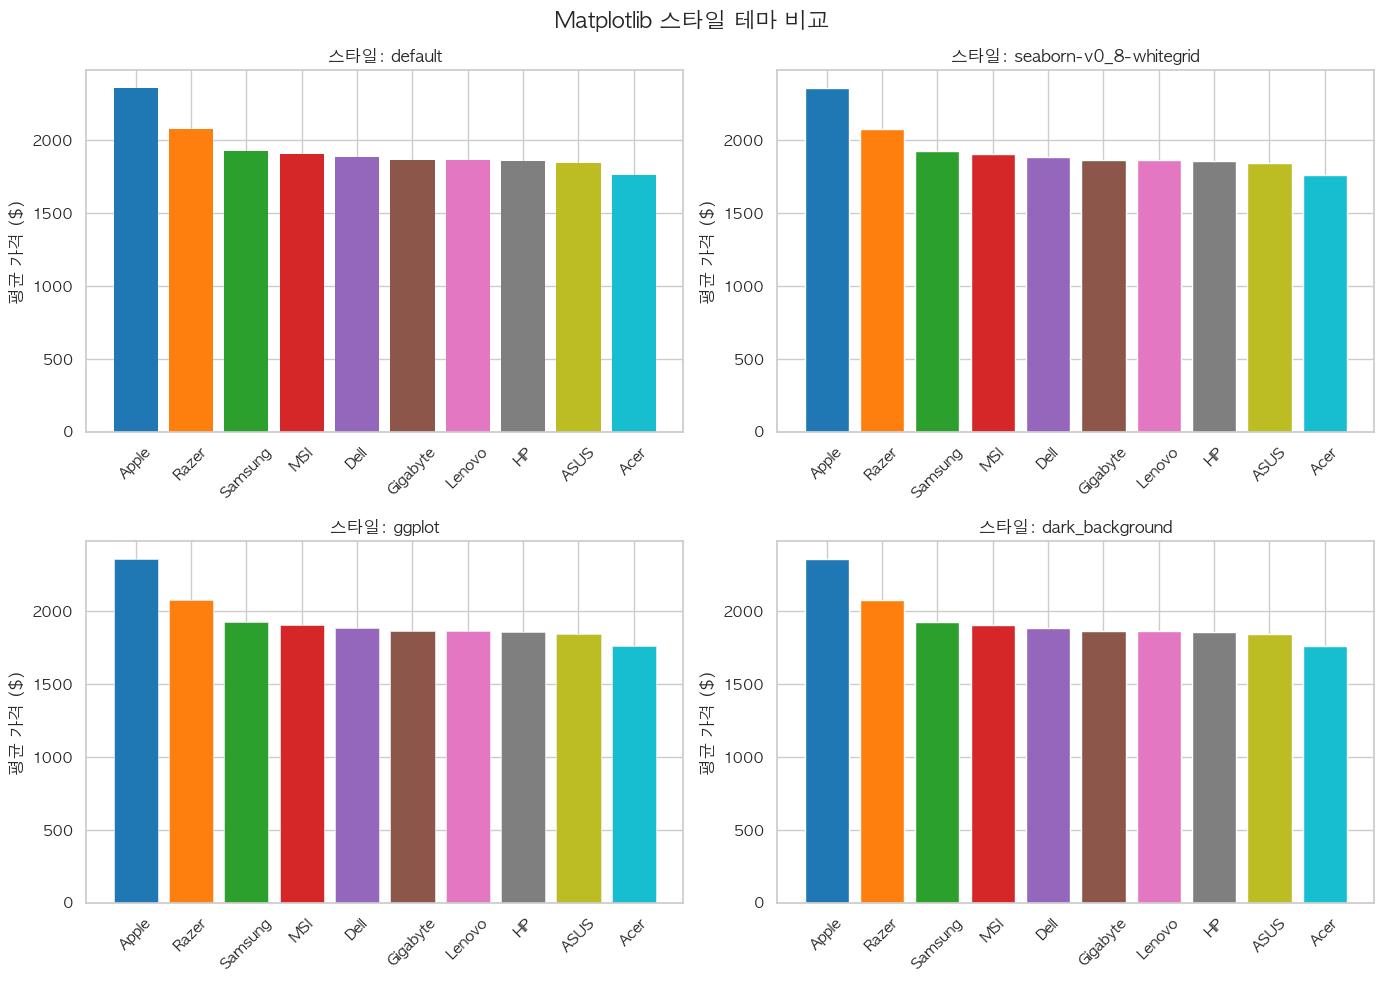

In [29]:
# 4가지 스타일 테마 비교
styles = ['default', 'seaborn-v0_8-whitegrid', 'ggplot', 'dark_background']
data_x = df_comp.groupby('brand')['price'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, style_name in zip(axes.flat, styles):
    with plt.style.context(style_name):
        ax.bar(data_x.index, data_x.values, color=plt.cm.tab10(range(len(data_x))))
        ax.set_title(f'스타일: {style_name}', fontsize=12, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        ax.set_ylabel('평균 가격 ($)')

fig.suptitle('Matplotlib 스타일 테마 비교', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 스타일 원복
sns.set_theme(style='whitegrid', font='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

---
# 📝 실전 연습문제

### [초급] 연습문제 1
**상하수도 데이터에서 읍면동별 총 사용요금을 계산하고, 상위 10개 읍면동을 수평 막대 그래프(barh)로 그리세요. 막대 끝에 금액을 표시하세요.**

> 힌트: `groupby` → `sum` → `sort_values` → `barh`

In [30]:
# 연습문제 1 풀이 공간




<details>
<summary>💡 연습문제 1 정답 (클릭하여 확인)</summary>

```python
dong_total = df_water.groupby('읍면동명')['사용요금'].sum().sort_values().tail(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(dong_total.index, dong_total.values, color='teal')
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f'{width:,.0f}원', ha='left', va='center', fontsize=10)
ax.set_title('읍면동별 총 사용요금 상위 10개', fontsize=14, fontweight='bold')
ax.set_xlabel('총 사용요금 (원)')
plt.tight_layout()
plt.show()
```
</details>

### [초급] 연습문제 2
**컴퓨터 데이터에서 OS별 평균 가격을 파이 차트로 그리세요. 비율(%)을 표시하고, 가장 비싼 OS 조각을 약간 분리(explode)시키세요.**

> 힌트: `groupby('os')['price'].mean()` → 가장 큰 값의 인덱스에 explode 적용

In [31]:
# 연습문제 2 풀이 공간




<details>
<summary>💡 연습문제 2 정답 (클릭하여 확인)</summary>

```python
os_avg = df_comp.groupby('os')['price'].mean()
explode = [0.1 if i == os_avg.idxmax() else 0 for i in os_avg.index]

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(os_avg.values, labels=os_avg.index, autopct='%1.1f%%',
       explode=explode, colors=plt.cm.Set2.colors, shadow=True, startangle=90)
ax.set_title('OS별 평균 가격 비율', fontsize=14, fontweight='bold')
plt.show()
```
</details>

### [중급] 연습문제 3
**Seaborn을 사용하여 캘리포니아 주택 데이터의 `median_income`, `housing_median_age`, `median_house_value` 3개 변수에 대한 pairplot을 그리세요. `median_house_value`를 3구간(저가/중가/고가)으로 나누어 hue로 색상 구분하세요.**

> 힌트: `pd.cut()` → `sns.pairplot(hue='가격대')`

In [32]:
# 연습문제 3 풀이 공간




<details>
<summary>💡 연습문제 3 정답 (클릭하여 확인)</summary>

```python
housing_sub = df_housing[['median_income', 'housing_median_age', 'median_house_value']].copy()
housing_sub['가격대'] = pd.cut(housing_sub['median_house_value'],
                              bins=3, labels=['저가', '중가', '고가'])

sns.pairplot(housing_sub, hue='가격대', palette='Set1',
             diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15}, height=3)
plt.suptitle('캘리포니아 주택 변수 관계도', fontsize=14, fontweight='bold', y=1.02)
plt.show()
```
</details>

### [중급] 연습문제 4
**사업자현황 데이터에서 시도별 남녀 전체 사업자 수를 계산하고, Seaborn의 barplot으로 시도별 막대를 성별(hue)로 나누어 그리세요. x축 라벨을 45도 회전시키세요.**

> 힌트: `sns.barplot(data=, x='시도', y='(전체)당월', hue='성별')`

In [33]:
# 연습문제 4 풀이 공간




<details>
<summary>💡 연습문제 4 정답 (클릭하여 확인)</summary>

```python
biz_sido = df_biz.groupby(['시도', '성별'], as_index=False)['(전체)당월'].sum()

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=biz_sido, x='시도', y='(전체)당월', hue='성별',
            palette='coolwarm', ax=ax)
ax.set_title('시도별 성별 사업자 수', fontsize=14, fontweight='bold')
ax.set_xlabel('시도')
ax.set_ylabel('사업자 수')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
```
</details>

### [고급] 연습문제 5
**컴퓨터 데이터를 사용하여 2×2 서브플롯 대시보드를 만드세요:**
1. 좌상: 브랜드별 평균 RAM (수평 막대)
2. 우상: 브랜드별 가격 분포 (박스플롯, Seaborn)
3. 좌하: CPU 코어 수 vs 가격 산점도 (색상=OS)
4. 우하: 스토리지 타입별 가격 분포 (바이올린플롯)

> 전체 제목(suptitle)을 추가하세요.

In [34]:
# 연습문제 5 풀이 공간




<details>
<summary>💡 연습문제 5 정답 (클릭하여 확인)</summary>

```python
sample = df_comp.sample(3000, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('컴퓨터 가격 종합 대시보드', fontsize=16, fontweight='bold')

# [0,0] 브랜드별 평균 RAM
brand_ram = df_comp.groupby('brand')['ram_gb'].mean().sort_values()
axes[0,0].barh(brand_ram.index, brand_ram.values, color='teal')
axes[0,0].set_title('브랜드별 평균 RAM', fontweight='bold')
axes[0,0].set_xlabel('평균 RAM (GB)')

# [0,1] 브랜드별 가격 분포 박스플롯
sns.boxplot(data=df_comp, x='brand', y='price', palette='Set2', ax=axes[0,1])
axes[0,1].set_title('브랜드별 가격 분포', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=45)

# [1,0] CPU 코어 vs 가격 산점도
sns.scatterplot(data=sample, x='cpu_cores', y='price',
                hue='os', alpha=0.5, palette='Set1', ax=axes[1,0])
axes[1,0].set_title('CPU 코어 vs 가격', fontweight='bold')

# [1,1] 스토리지 타입별 가격 바이올린
sns.violinplot(data=df_comp, x='storage_type', y='price',
               palette='muted', ax=axes[1,1])
axes[1,1].set_title('스토리지 타입별 가격', fontweight='bold')

plt.tight_layout()
plt.show()
```
</details>

---
# 수업 정리

### 1교시 - Matplotlib 기초
| 차트 | 함수 | 용도 |
|------|------|------|
| 선 그래프 | `plt.plot()` / `ax.plot()` | 추세, 시계열 |
| 막대 그래프 | `plt.bar()` / `plt.barh()` | 범주별 크기 비교 |
| 히스토그램 | `plt.hist()` | 수치형 분포 |
| 산점도 | `plt.scatter()` | 두 변수의 관계 |
| 파이 차트 | `plt.pie()` | 전체 대비 비율 |
| 서브플롯 | `plt.subplots(nrows, ncols)` | 여러 그래프 배치 |

### 2교시 - Seaborn 기초~중급
| 차트 | 함수 | 용도 |
|------|------|------|
| 카운트플롯 | `sns.countplot()` | 범주별 빈도 |
| 히스토그램 | `sns.histplot()` | 분포 (KDE 포함) |
| KDE 플롯 | `sns.kdeplot()` | 부드러운 밀도 곡선 |
| 박스플롯 | `sns.boxplot()` | 분포 + 이상치 |
| 바이올린 | `sns.violinplot()` | 분포 형태 + 통계 |
| 막대플롯 | `sns.barplot()` | 평균 + 신뢰구간 |
| 히트맵 | `sns.heatmap()` | 상관관계, 교차표 |
| 산점도 | `sns.scatterplot()` | 다차원 관계 |
| 회귀선 | `sns.regplot()` | 산점도 + 추세선 |
| 페어플롯 | `sns.pairplot()` | 변수 쌍별 관계 |

### 3교시 - 고급 시각화
| 기법 | 방법 | 용도 |
|------|------|------|
| 주석/화살표 | `ax.annotate()` | 핵심 데이터 강조 |
| 텍스트 박스 | `ax.text(bbox=...)` | 요약 정보 표시 |
| 기준선 | `ax.axhline()` / `ax.axvline()` | 임계값 표시 |
| GridSpec | `GridSpec(nrows, ncols)` | 불균등 레이아웃 |
| 스타일 | `plt.style.context()` | 테마 변경 |
| 컬러맵 | `cmap='YlOrRd'` 등 | 연속형 색상 표현 |

### 자주 쓰는 컬러맵
| 이름 | 용도 |
|------|------|
| `viridis` / `plasma` | 일반 순차형 |
| `YlOrRd` / `Blues` | 히트맵 |
| `RdBu_r` / `coolwarm` | 양극성 (상관관계) |
| `Set1` / `Set2` / `Set3` | 범주형 구분 |
| `Pastel1` / `Pastel2` | 부드러운 범주형 |

수고하셨습니다! 🎉